# U-Net Glomeruli Segmentation — Binary Segmentation Training Pipeline

This notebook implements a complete PyTorch U-Net training system for binary semantic segmentation of glomeruli from renal biopsy whole-slide images.

## Two-Model Strategy

This pipeline uses a **two-stage approach** for glomeruli classification:

1. **Model 1 (this notebook)**: Binary segmentation to detect glomerulus locations
   - Input: Z-score normalized RGB tiles from WSI
   - Output: Pixel-level binary masks (background vs glomerulus)
   - Classes: 0 (background), 1 (glomerulus — fused from original classes 1-4)
   - Purpose: Localizes all glomeruli regardless of subtype

2. **Model 2 (future)**: Classifier on detected patches to assign classes 1-4
   - Input: Image patches extracted from detected glomerulus regions (Model 1)
   - Output: Per-glomerulus classification (classes 1-4: FGS, MPGN, FSGS, other)
   - Purpose: Fine-grained subtype classification for clinical diagnosis

## Notebook Contents

1. **Data Loading** — GlomeruliDataset with grouped split and online augmentation (train only)
2. **Loss Functions** — BCEWithLogits + Dice for binary segmentation
3. **U-Net Architecture** — Encoder-Decoder with Skip Connections
4. **Binary Segmentation Metrics** — Accuracy, Precision, Recall, F1, ROC-AUC, Dice
5. **Training Pipeline** — Full training loop with validation and checkpointing

## Pipeline Overview

WSI TIFF + GeoJSON annotations → Tiled images + masks (classes 0-4) →
Reinhard color normalization → Z-score standardization →
Train/Val/Test split (grouped by biopsy, 70/15/15) →
Online augmentation (train only) → U-Net training → Model evaluation (Binary Metrics)

See WORKFLOW.md for end-to-end pipeline documentation.

In [ ]:
# Standard library
import os
import json
import time
from pathlib import Path
from datetime import datetime
from typing import Tuple
import random
import re

# Scientific computing
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR
from torch.cuda.amp import autocast, GradScaler
from torch.utils.tensorboard import SummaryWriter
import albumentations as A

# Data loading
import cv2
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, WeightedRandomSampler
import warnings

# Progress/model library imports
from tqdm.auto import tqdm
import segmentation_models_pytorch as smp
from PIL import Image, ImageFile
from skimage.measure import label, regionprops
from scipy import ndimage as _ndi
from skimage.segmentation import watershed as _watershed
from skimage.feature import peak_local_max as _plm
import matplotlib.pyplot as plt
import glob
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
from scipy.ndimage import label as scipy_label, distance_transform_edt
from matplotlib import patches
from skimage.measure import find_contours
import pandas as pd
from IPython.display import Image as IPImage, display


# Allow PIL to load truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# --- Default threshold values for postprocessing ---
DEFAULT_THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]
# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# --- CUDA performance tuning (T4 Tensor Cores) ---
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True          # auto-tune conv algorithms
    torch.backends.cuda.matmul.allow_tf32 = True   # TF32 for matmul (T4 supports it)
    torch.backends.cudnn.allow_tf32 = True         # TF32 for cudnn convolutions
    print(f"cudnn.benchmark: {torch.backends.cudnn.benchmark}")
    print(f"CUDA matmul TF32: {torch.backends.cuda.matmul.allow_tf32}")
    print(f"cudnn TF32: {torch.backends.cudnn.allow_tf32}")
    print(f"PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True")


# --- Preprocessing Transforms (Reinhard Normalization + Z-score) ---

class ReinhardNormalize:
    """Reinhard stain normalization in LAB color space for consistency across slides."""

    def __init__(self, target_stats: dict):
        self.target = target_stats

    @staticmethod
    def _get_tissue_mask(img_bgr: np.ndarray) -> np.ndarray:
        """Isolate tissue pixels from background and artifacts via luminance and saturation thresholds."""
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
        hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        mask = (lab[:, :, 0] < 230) & (hsv[:, :, 1] > 10)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        mask = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        return mask.astype(bool)

    @staticmethod
    def compute_template_stats(image_paths: list, n_samples: int = 200) -> dict:
        """Compute median LAB statistics from tissue pixels to define normalization target."""
        paths_list = list(image_paths)[:n_samples]
        sample = random.sample(paths_list, min(n_samples, len(paths_list)))
        all_stats = []
        
        for p in sample:
            img = cv2.imread(str(p))
            if img is None:
                continue
            tissue = ReinhardNormalize._get_tissue_mask(img)
            if tissue.sum() < 100:
                continue
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
            stats = ([lab[..., c][tissue].mean() for c in range(3)] +
                     [lab[..., c][tissue].std()  for c in range(3)])
            all_stats.append(stats)
        
        if not all_stats:
            return {'mean_L': 50, 'mean_a': 128, 'mean_b': 128,
                    'std_L': 10, 'std_a': 10, 'std_b': 10}
        
        arr = np.array(all_stats)
        keys = ['mean_L', 'mean_a', 'mean_b', 'std_L', 'std_a', 'std_b']
        return {k: float(np.median(arr[:, i])) for i, k in enumerate(keys)}

    def __call__(self, img_bgr: np.ndarray) -> np.ndarray:
        """Normalize image to match template statistics, preserving background pixels."""
        tissue = self._get_tissue_mask(img_bgr)
        if tissue.sum() < 100:
            return img_bgr
        
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
        
        src = {c: (lab[..., i][tissue].mean(), lab[..., i][tissue].std())
               for i, c in enumerate(['L', 'a', 'b'])}
        
        result = lab.copy()
        for i, c in enumerate(['L', 'a', 'b']):
            m, s = src[c]
            result[..., i] = ((lab[..., i] - m) *
                              (self.target[f'std_{c}'] / (s + 1e-5)) +
                              self.target[f'mean_{c}'])
        
        result[~tissue] = lab[~tissue]
        result = np.clip(result, 0, 255).astype(np.uint8)
        return cv2.cvtColor(result, cv2.COLOR_LAB2BGR)


def compute_channel_stats(
    image_paths: list,
    n_samples: int = 200,
    reinhard_norm=None,
    std_floor: float = 0.03,
) -> Tuple[list, list]:
    """Compute weighted per-channel RGB stats from tissue pixels for Z-score normalization."""
    paths_list = list(image_paths)
    sample = random.sample(paths_list, min(n_samples, len(paths_list)))
    
    tile_means, tile_vars, tile_counts = [], [], []
    skipped_count = 0
    for p in sample:
        img_bgr = cv2.imread(str(p))
        if img_bgr is None:
            skipped_count += 1
            continue
        tissue = ReinhardNormalize._get_tissue_mask(img_bgr)
        if tissue.sum() < 100:
            skipped_count += 1
            continue

        if reinhard_norm is not None:
            img_bgr = reinhard_norm(img_bgr)

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        pixels = img_rgb[tissue]
        tile_means.append(pixels.mean(0))
        tile_vars.append(pixels.var(0))
        tile_counts.append(tissue.sum())
    
    if not tile_means:
        print(f"  ⚠️  WARNING: No valid tissue pixels found in {len(sample)} samples!")
        print(f"      {skipped_count} samples were skipped (tissue.sum() < 100 or read failed)")
        print(f"      Falling back to default values [0.5, 0.5, 0.5] and [0.2, 0.2, 0.2]")
        print(f"      This will make Z-score normalization INEFFECTIVE.")
        return [0.5, 0.5, 0.5], [0.2, 0.2, 0.2]
    
    print(f"  ✓ Computed stats from {len(tile_means)} valid samples (skipped {skipped_count})")
    
    means_arr = np.array(tile_means)
    vars_arr = np.array(tile_vars)
    counts_arr = np.array(tile_counts, dtype=np.float64)
    w = counts_arr / counts_arr.sum()
    
    mean = (means_arr * w[:, None]).sum(0)
    var = ((vars_arr + (means_arr - mean) ** 2) * w[:, None]).sum(0)
    std = np.sqrt(var)
    std = np.maximum(std, std_floor)
    return mean.tolist(), std.tolist()

Using device: cuda
GPU: Tesla T4
VRAM: 17.00 GB
cudnn.benchmark: True
CUDA matmul TF32: True
cudnn TF32: True
PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True


In [2]:
def _collect_image_tiles(images_dir: str) -> list:
    """Collect input PNG tiles while excluding masks and generated mask files."""
    images_dir = Path(images_dir)
    image_paths = sorted(images_dir.glob('*/images/*.png'))

    # Fallback for flat/custom datasets: include PNGs except anything inside a masks folder
    # or files already named *_mask.png.
    if not image_paths:
        image_paths = sorted(
            p for p in images_dir.rglob('*.png')
            if 'masks' not in p.relative_to(images_dir).parts
            and not p.stem.endswith('_mask')
        )

    return image_paths


def _slide_name_from_image_path(image_path, images_dir) -> str:
    """Infer the biopsy/slide name from a tile path under <root>/<slide>/images/*.png."""
    image_path = Path(image_path)
    images_dir = Path(images_dir)
    try:
        rel = image_path.relative_to(images_dir)
        if len(rel.parts) >= 3 and rel.parts[1] == 'images':
            return rel.parts[0]
    except ValueError as e:
        warnings.warn(f'Path format issue for {image_path}: {e}')
        return None

    if image_path.parent.name == 'images' and image_path.parent.parent.name:
        return image_path.parent.parent.name
    return image_path.parent.name or image_path.stem


def _group_images_by_biopsy(image_paths: list, images_dir: str) -> dict:
    """Group image paths by biopsy/slide folder, supporting canonical and flat layouts."""
    images_dir = Path(images_dir)
    biopsias_dict = {}
    for img_path in image_paths:
        biopsia = _slide_name_from_image_path(img_path, images_dir)
        biopsias_dict.setdefault(biopsia, []).append(img_path)
    return biopsias_dict


def _safe_train_val_test_split(
    biopsias_list: list,
    train_size: float = 0.70,
    val_size: float = 0.15,
    seed: int = 42,
) -> Tuple[list, list, list]:
    """Split biopsy IDs without crashing on tiny datasets."""
    test_size = 1.0 - train_size - val_size
    assert test_size >= 0, "train_size + val_size must be <= 1.0"

    biopsias_list = list(biopsias_list)
    if not biopsias_list:
        return [], [], []

    # sklearn.train_test_split raises on very small lists. Keep deterministic, leak-free
    # biopsy-level splits and prefer having train data in quick/smoke-test datasets.
    if len(biopsias_list) == 1:
        return biopsias_list, [], []
    if len(biopsias_list) == 2:
        rng = random.Random(seed)
        shuffled = biopsias_list[:]
        rng.shuffle(shuffled)
        return [shuffled[0]], [shuffled[1]], []

    if test_size > 0:
        train_val_biopsias, test_biopsias = train_test_split(
            biopsias_list,
            test_size=test_size,
            random_state=seed,
        )
    else:
        train_val_biopsias = biopsias_list
        test_biopsias = []

    if val_size > 0 and len(train_val_biopsias) > 1:
        val_fraction = val_size / (train_size + val_size)
        train_biopsias, val_biopsias = train_test_split(
            train_val_biopsias,
            test_size=val_fraction,
            random_state=seed + 1,
        )
    else:
        train_biopsias = train_val_biopsias
        val_biopsias = []

    return train_biopsias, val_biopsias, test_biopsias


def split_biopsias(
    images_dir: str,
    train_size: float = 0.70,
    val_size: float = 0.15,
    seed: int = 42,
) -> Tuple[list, list, list, dict]:
    """Groups biopsias into train/val/test to prevent data leakage at slide level."""
    images_dir = Path(images_dir)
    all_images = _collect_image_tiles(images_dir)

    if not all_images:
        raise ValueError(f"No PNG image tiles found in {images_dir}. Expected files under */images/*.png")

    biopsias_dict = _group_images_by_biopsy(all_images, images_dir)
    train_biopsias, val_biopsias, test_biopsias = _safe_train_val_test_split(
        list(biopsias_dict.keys()),
        train_size=train_size,
        val_size=val_size,
        seed=seed,
    )

    return train_biopsias, val_biopsias, test_biopsias, biopsias_dict


def load_rgb_image(image_path: str) -> np.ndarray:
    """Load an RGB uint8 image with PIL tolerance for truncated files."""
    try:
        return np.array(Image.open(str(image_path)).convert('RGB'))
    except Exception as exc:
        raise RuntimeError(f"Failed to load image {image_path}: {exc}") from exc


def load_binary_mask(mask_path: str) -> np.ndarray:
    """Load a grayscale mask and binarize all non-zero classes as glomerulus."""
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise RuntimeError(f"Failed to load mask: {mask_path}")
    return (mask > 0).astype(np.uint8)


def preprocess_rgb_image(
    img_rgb: np.ndarray,
    reinhard_norm=None,
    channel_means: list = None,
    channel_stds: list = None,
) -> np.ndarray:
    """Apply the same RGB -> Reinhard -> RGB/255 -> Z-score preprocessing used by the dataset."""
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    if reinhard_norm is not None:
        img_bgr = reinhard_norm(img_bgr)

    img_float = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    if channel_means is not None and channel_stds is not None:
        means = np.asarray(channel_means, dtype=np.float32)
        stds = np.asarray(channel_stds, dtype=np.float32)
        img_float = (img_float - means) / (stds + 1e-6)
    return img_float


def tensor_from_preprocessed_rgb(img_float: np.ndarray, device: torch.device = None) -> torch.Tensor:
    """Convert preprocessed HWC RGB float image to a BCHW float tensor."""
    tensor = torch.from_numpy(np.transpose(img_float, (2, 0, 1))).float().unsqueeze(0)
    return tensor.to(device) if device is not None else tensor


def make_mask_overlay(img_rgb: np.ndarray, mask_binary: np.ndarray, color=(255, 0, 0), alpha: float = 0.4) -> np.ndarray:
    """Blend a binary mask over an RGB image."""
    overlay = img_rgb.copy().astype(np.float32)
    overlay[mask_binary.astype(bool)] = color
    return cv2.addWeighted(img_rgb, 1 - alpha, overlay.astype(np.uint8), alpha, 0)


# ============================================================================
# Grayscale pixel values that correspond to glomerulus classes (any > 0 in practice)
# 64=No_Proliferativo, 128=Proliferativo, 192=Esclerosado, 255=Excluido/Excluyente
# Excluido (255) is INTENTIONALLY mapped to Glomerulus class 1 for binary segmentation
# ============================================================================
class GlomeruliDataset(Dataset):
    """Loads paired image-mask glomeruli tiles with online preprocessing and augmentation."""

    def __init__(
        self,
        images_dir: str,
        masks_dir: str = None,
        split: str = 'train',
        biopsias: list = None,
        biopsias_dict: dict = None,
        reinhard_norm=None,
        channel_means: list = None,
        channel_stds: list = None,
        train_size: float = 0.70,
        val_size: float = 0.15,
        seed: int = 42,
        transforms=None,
    ):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir) if masks_dir is not None else Path(images_dir)
        self.split = split
        self.transforms = transforms
        self.reinhard_norm = reinhard_norm
        self.channel_means = channel_means if channel_means is not None else [0.5, 0.5, 0.5]
        self.channel_stds = channel_stds if channel_stds is not None else [0.2, 0.2, 0.2]

        assert split in {'train', 'val', 'test'}, f"Invalid split: {split}"
        assert self.images_dir.exists(), f"Images dir not found: {self.images_dir}"
        assert self.masks_dir.exists(), f"Masks dir not found: {self.masks_dir}"

        if biopsias is not None and biopsias_dict is not None:
            selected_biopsias = biopsias
            self.biopsias_dict = biopsias_dict
        else:
            train_biopsias, val_biopsias, test_biopsias, self.biopsias_dict = split_biopsias(
                self.images_dir,
                train_size=train_size,
                val_size=val_size,
                seed=seed,
            )
            selected_biopsias = {
                'train': train_biopsias,
                'val': val_biopsias,
                'test': test_biopsias,
            }[split]

        self.image_paths = []
        for biopsia in selected_biopsias:
            self.image_paths.extend(self.biopsias_dict.get(biopsia, []))

        self.image_paths = sorted(self.image_paths)

        paired = []
        missing = []
        for img_path in self.image_paths:
            mask_path = self._get_mask_path(img_path)
            if mask_path.exists():
                paired.append((img_path, mask_path))
            else:
                missing.append((img_path, mask_path))

        if missing:
            warnings.warn(
                f"Found {len(missing)} images without corresponding masks. "
                f"These will be skipped. First few: {missing[:3]}"
            )

        if not paired:
            raise ValueError("No valid image-mask pairs found after checking.")

        self.image_paths, self.mask_paths = zip(*paired)
        self.image_paths = list(self.image_paths)
        self.mask_paths = list(self.mask_paths)
        
        # Caches used by the train sampler/audits
        self._positive_flags = None
        self._tile_metadata = None
        self._annotation_tiles_by_key = None

    def _get_mask_path(self, image_path: Path) -> Path:
        """Convert image tile path to its mask path, supporting canonical and flat layouts."""
        rel = image_path.relative_to(self.images_dir)
        parts = list(rel.parts)
        stem = Path(parts[-1]).stem

        if len(parts) >= 3 and parts[1] == 'images':
            parts[1] = 'masks'
            parts[-1] = f"{stem}_mask.png"
            return self.masks_dir / Path(*parts)

        # Flat/custom fallback: first try <masks_dir>/<stem>_mask.png, then masks/<stem>_mask.png.
        flat_mask = self.masks_dir / f"{stem}_mask.png"
        if flat_mask.exists():
            return flat_mask
        return self.masks_dir / 'masks' / f"{stem}_mask.png"

    def get_positive_flags(self) -> list:
        """Return list of bools: True if tile mask contains at least one glomerulus pixel.
        
        Used by WeightedRandomSampler. Reads mask files once at dataset init time.
        Masks are small enough (1024x1024 uint8 = 1MB) that this is feasible.
        Caches result to avoid double scan.
        """
        if self._positive_flags is not None:
            return self._positive_flags
        
        flags = []
        for mask_path in self.mask_paths:
            try:
                flags.append(bool(np.any(load_binary_mask(mask_path))))
            except RuntimeError:
                flags.append(False)
        self._positive_flags = flags
        return flags

    def _load_annotation_tiles_by_key(self) -> dict:
        """Index per-slide annotations.json entries by (slide_folder, tile image path)."""
        if self._annotation_tiles_by_key is not None:
            return self._annotation_tiles_by_key

        tiles_by_key = {}
        for ann_path in sorted(self.images_dir.glob('*/annotations.json')):
            slide_folder = ann_path.parent.name
            try:
                with ann_path.open('r', encoding='utf-8') as f:
                    annotations = json.load(f)
            except Exception as exc:
                warnings.warn(f"Could not read annotations metadata from {ann_path}: {exc}")
                continue

            slide_name = annotations.get('slide') or slide_folder
            for tile in annotations.get('tiles', []):
                image_rel = tile.get('image')
                if not image_rel:
                    continue

                image_rel = str(Path(image_rel).as_posix())
                meta = dict(tile)
                meta['slide'] = slide_name
                meta['slide_folder'] = slide_folder
                meta['annotations_path'] = str(ann_path)

                # Support both the folder name and the slide name in case they differ.
                tiles_by_key[(slide_folder, image_rel)] = meta
                tiles_by_key[(slide_name, image_rel)] = meta

        self._annotation_tiles_by_key = tiles_by_key
        return tiles_by_key

    def get_tile_metadata(self, idx: int) -> dict:
        """Return annotations.json metadata for a dataset tile, or {} if unavailable."""
        if self._tile_metadata is None:
            tiles_by_key = self._load_annotation_tiles_by_key()
            metadata = []
            for image_path in self.image_paths:
                try:
                    rel = image_path.relative_to(self.images_dir)
                    slide_folder = rel.parts[0]
                    image_rel = Path(*rel.parts[1:]).as_posix()
                except Exception:
                    metadata.append({})
                    continue

                metadata.append(tiles_by_key.get((slide_folder, image_rel), {}))

            self._tile_metadata = metadata

        return self._tile_metadata[idx] if 0 <= idx < len(self._tile_metadata) else {}

    def get_sampling_weights(
        self,
        secondary_factor: float = 0.35,
        duplicate_aware: bool = True,
    ) -> Tuple[torch.Tensor, dict]:
        """Compute train-sampling weights with optional duplicate-aware glomerulus balancing."""
        positive_flags = self.get_positive_flags()
        n_positive = int(sum(positive_flags))
        n_negative = int(len(positive_flags) - n_positive)

        report = {
            'mode': 'simple',
            'n_positive': n_positive,
            'n_negative': n_negative,
            'num_unique_glomeruli': 0,
            'primary_links': 0,
            'secondary_links': 0,
            'unmatched_positive_tiles': 0,
        }

        if n_positive == 0 or n_negative == 0:
            return None, report

        def simple_weights(mode: str = 'simple'):
            report['mode'] = mode
            weight_pos = 1.0 / n_positive
            weight_neg = 1.0 / n_negative
            return torch.tensor(
                [weight_pos if flag else weight_neg for flag in positive_flags],
                dtype=torch.float32,
            ), report

        if not duplicate_aware:
            return simple_weights('simple')

        glomerulus_entries = {}
        for idx, is_positive in enumerate(positive_flags):
            if not is_positive:
                continue

            meta = self.get_tile_metadata(idx)
            glomeruli = meta.get('glomeruli') if meta else None
            if not glomeruli:
                continue

            slide = meta.get('slide') or meta.get('slide_folder') or _slide_name_from_image_path(
                self.image_paths[idx], self.images_dir
            )
            for glom in glomeruli:
                glom_id = glom.get('id')
                if glom_id is None:
                    continue

                role = str(glom.get('role', 'primary')).lower()
                try:
                    coverage = max(float(glom.get('coverage_pct', 0.0)), 0.0) / 100.0
                except (TypeError, ValueError):
                    coverage = 0.0

                role_factor = secondary_factor if role == 'secondary' else 1.0
                raw_weight = max(coverage, 1e-6) * role_factor
                key = (str(slide), str(glom_id))
                glomerulus_entries.setdefault(key, []).append((idx, raw_weight, role))

                if role == 'secondary':
                    report['secondary_links'] += 1
                else:
                    report['primary_links'] += 1

        if not glomerulus_entries:
            warnings.warn(
                "Duplicate-aware sampler requested, but no usable glomerulus metadata was found. "
                "Falling back to simple positive/negative balancing."
            )
            return simple_weights('fallback-simple-no-annotations')

        positive_mass = np.zeros(len(positive_flags), dtype=np.float64)
        for entries in glomerulus_entries.values():
            total = sum(raw for _, raw, _ in entries)
            if total <= 0:
                continue
            for idx, raw, _ in entries:
                positive_mass[idx] += raw / total

        unmatched_positive_tiles = 0
        for idx, is_positive in enumerate(positive_flags):
            if is_positive and positive_mass[idx] <= 0:
                # Keep mask-positive tiles with missing/partial metadata trainable.
                positive_mass[idx] = 1.0
                unmatched_positive_tiles += 1

        total_positive_mass = float(positive_mass.sum())
        if total_positive_mass <= 0:
            warnings.warn(
                "Duplicate-aware sampler produced zero positive mass. "
                "Falling back to simple positive/negative balancing."
            )
            return simple_weights('fallback-simple-zero-positive-mass')

        weights = np.zeros(len(positive_flags), dtype=np.float64)
        for idx, is_positive in enumerate(positive_flags):
            if is_positive:
                weights[idx] = positive_mass[idx] / total_positive_mass
            else:
                weights[idx] = 1.0 / n_negative

        report.update({
            'mode': 'duplicate-aware',
            'num_unique_glomeruli': len(glomerulus_entries),
            'unmatched_positive_tiles': unmatched_positive_tiles,
            'positive_weight_sum': float(weights[np.array(positive_flags, dtype=bool)].sum()),
            'negative_weight_sum': float(weights[~np.array(positive_flags, dtype=bool)].sum()),
            'secondary_factor': secondary_factor,
        })
        return torch.tensor(weights, dtype=torch.float32), report

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Load RGB tile -> Reinhard normalization -> augment -> Z-score -> tensors."""
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        img_rgb = load_rgb_image(img_path)
        mask_binary = load_binary_mask(mask_path)

        if self.reinhard_norm is not None:
            img_bgr = self.reinhard_norm(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        if self.transforms is not None:
            augmented = self.transforms(image=img_rgb, mask=mask_binary)
            img_rgb = augmented['image']
            mask_binary = augmented['mask']

        img_float = preprocess_rgb_image(
            img_rgb,
            reinhard_norm=None,  # already applied before augmentation when configured
            channel_means=self.channel_means,
            channel_stds=self.channel_stds,
        )
        img_tensor = torch.from_numpy(np.transpose(img_float, (2, 0, 1))).float()
        mask_tensor = torch.from_numpy(mask_binary.astype(np.int64)).long()

        return img_tensor, mask_tensor

In [3]:
def create_dataloaders(
    images_dir: str,
    masks_dir: str = None,
    batch_size: int = 4,
    num_workers: int = 4,
    seed: int = 42,
    train_transforms=None,
    val_transforms=None,
    reinhard_norm=None,
    channel_means: list = None,
    channel_stds: list = None,
):
    """Create train/val/test DataLoaders with pre-computed grouped splits by biopsia and positive/negative balancing."""
    train_biopsias, val_biopsias, test_biopsias, biopsias_dict = split_biopsias(
        images_dir=images_dir,
        train_size=0.70,
        val_size=0.15,
        seed=seed,
    )

    train_ds = GlomeruliDataset(
        images_dir,
        masks_dir,
        split='train',
        biopsias=train_biopsias,
        biopsias_dict=biopsias_dict,
        reinhard_norm=reinhard_norm,
        channel_means=channel_means,
        channel_stds=channel_stds,
        transforms=train_transforms,
    )

    val_ds = GlomeruliDataset(
        images_dir,
        masks_dir,
        split='val',
        biopsias=val_biopsias,
        biopsias_dict=biopsias_dict,
        reinhard_norm=reinhard_norm,
        channel_means=channel_means,
        channel_stds=channel_stds,
        transforms=val_transforms,
    )

    test_ds = GlomeruliDataset(
        images_dir,
        masks_dir,
        split='test',
        biopsias=test_biopsias,
        biopsias_dict=biopsias_dict,
        reinhard_norm=reinhard_norm,
        channel_means=channel_means,
        channel_stds=channel_stds,
        transforms=None,
    )

    # ========== WeightedRandomSampler: positive/negative balance + duplicate-aware positives ==========
    print("Computing duplicate-aware sampling weights for WeightedRandomSampler...")
    positive_flags = train_ds.get_positive_flags()
    n_positive = sum(positive_flags)
    n_negative = len(positive_flags) - n_positive
    print(f"  Positive tiles (contain glomerulus): {n_positive:,}")
    print(f"  Negative tiles (background only):    {n_negative:,}")

    sample_weights, sampler_report = train_ds.get_sampling_weights(
        secondary_factor=0.35,
        duplicate_aware=True,
    )

    if sample_weights is None:
        warnings.warn(
            f"Cannot balance sampler: positives={n_positive}, negatives={n_negative}. "
            "Falling back to normal shuffle."
        )
        sampler = None
        shuffle_train = True
    else:
        num_samples = min(len(positive_flags), 2 * n_positive)
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=num_samples,
            replacement=True,
        )
        shuffle_train = False
        print(f"  Sampler mode: {sampler_report.get('mode')}")
        print(f"  Unique glomeruli in train metadata: {sampler_report.get('num_unique_glomeruli', 0):,}")
        print(f"  Primary tile links:   {sampler_report.get('primary_links', 0):,}")
        print(f"  Secondary tile links: {sampler_report.get('secondary_links', 0):,}")
        if sampler_report.get('unmatched_positive_tiles', 0):
            print(f"  Positive tiles without annotation metadata: {sampler_report['unmatched_positive_tiles']:,}")
        if 'positive_weight_sum' in sampler_report and 'negative_weight_sum' in sampler_report:
            print(
                f"  Weight mass: pos={sampler_report['positive_weight_sum']:.3f}, "
                f"neg={sampler_report['negative_weight_sum']:.3f}"
            )
        print(f"  WeightedRandomSampler: {num_samples:,} samples/epoch (~1:1 pos:neg ratio)")

    train_loader = torch.utils.data.DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=shuffle_train,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0),
        prefetch_factor=3 if num_workers > 0 else None,
    )

    val_loader = torch.utils.data.DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0),
        prefetch_factor=2 if num_workers > 0 else None,
    )

    test_loader = torch.utils.data.DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0),
        prefetch_factor=2 if num_workers > 0 else None,
    )

    return train_loader, val_loader, test_loader

In [4]:
# Quick test of dataset loading
if Path('Salidas/Tiles_UNet').exists():
    ds_test = GlomeruliDataset('Salidas/Tiles_UNet', split='train')
    print(f"Dataset loaded: {len(ds_test)} tiles")
    print(f"First image path: {ds_test.image_paths[0]}")
    print(f"First mask path:  {ds_test.mask_paths[0]}")

    img, mask = ds_test[0]
    print(f"Image shape: {img.shape}, dtype: {img.dtype}")
    print(f"Mask shape: {mask.shape}, dtype: {mask.dtype}")
    print(f"Mask unique classes (binary): {torch.unique(mask).tolist()}")
    print(f"Class distribution: 0 (background)={torch.sum(mask == 0).item()}, 1 (glomerulus)={torch.sum(mask == 1).item()}")

    positive_idx = next((i for i, p in enumerate(ds_test.mask_paths) if cv2.imread(str(p), cv2.IMREAD_GRAYSCALE).max() > 0), None)
    if positive_idx is not None:
        _, positive_mask = ds_test[positive_idx]
        print(f"Positive mask sanity check at idx={positive_idx}: classes={torch.unique(positive_mask).tolist()}, "
              f"glomerulus_pixels={torch.sum(positive_mask == 1).item()}")
    else:
        warnings.warn("No positive masks found in this split. Check tiling annotations or split selection.")
else:
    print("Dataset directory not found. Run preprocessing pipeline first.")
    print("Required: tiling_unet.py -> normalizacion.py")



Dataset loaded: 10712 tiles
First image path: Salidas\Tiles_UNet\18-139\images\18-139_centered_g0002.png
First mask path:  Salidas\Tiles_UNet\18-139\masks\18-139_centered_g0002_mask.png
Image shape: torch.Size([3, 1024, 1024]), dtype: torch.float32
Mask shape: torch.Size([1024, 1024]), dtype: torch.int64
Mask unique classes (binary): [0, 1]
Class distribution: 0 (background)=769779, 1 (glomerulus)=278797
Positive mask sanity check at idx=0: classes=[0, 1], glomerulus_pixels=278797


# Visual Data Exploration — Glomeruli Samples & Masks

In this section, we visualize the raw data: tiles from biopsies with their corresponding binary masks. 
The masks show glomerulus regions (red overlay) on the histological image.

In [5]:
def visualize_tiles_and_masks(images_dir, n_tiles=6, figsize=(20, 8)):
    """
    Visualize random positive tiles with their binary masks overlaid in red.
    
    Args:
        images_dir: Root directory with tile data (Salidas/Tiles_UNet)
        n_tiles: Number of tiles to show
        figsize: Figure size
    """
    # Get dataset to find positive tiles
    ds = GlomeruliDataset(images_dir, split='train', reinhard_norm=None, 
                          channel_means=None, channel_stds=None)
    positive_flags = ds.get_positive_flags()
    positive_indices = [i for i, flag in enumerate(positive_flags) if flag]
    
    if len(positive_indices) == 0:
        print("No positive tiles found")
        return
    
    # Sample n_tiles random positives
    random.seed(42)
    selected_indices = random.sample(positive_indices, min(n_tiles, len(positive_indices)))
    
    fig, axes = plt.subplots(2, len(selected_indices), figsize=figsize)
    if len(selected_indices) == 1:
        axes = axes.reshape(2, 1)
    
    for col, idx in enumerate(selected_indices):
        image_path = ds.image_paths[idx]
        mask_path = ds._get_mask_path(image_path)
        
        # Load image
        img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_binary = (mask > 0).astype(np.uint8)
        
        # Row 0: Original image
        axes[0, col].imshow(img_rgb)
        axes[0, col].set_title(f"Tile {idx}\n{Path(image_path).parent.parent.name}", fontsize=10)
        axes[0, col].axis('off')
        
        # Row 1: Overlay mask on image
        blended = make_mask_overlay(img_rgb, mask_binary, color=(255, 0, 0), alpha=0.4)
        
        axes[1, col].imshow(blended)
        axes[1, col].set_title(f"Mask Overlay", fontsize=10)
        axes[1, col].axis('off')
    
    plt.suptitle("Sample Positive Tiles with Binary Masks", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()

In [6]:
RUN_VISUALIZE_TILE_AND_MASK = False

if RUN_VISUALIZE_TILE_AND_MASK and Path('Salidas/Tiles_UNet').exists():
    visualize_tiles_and_masks('Salidas/Tiles_UNet', n_tiles=6, figsize=(20, 8))

In [7]:
class BinaryDiceLoss(nn.Module):
    """Sørensen-Dice coefficient for 1-channel binary logits (sigmoid output)."""

    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits: [B, 1, H, W] raw logits from smp model
            targets: [B, H, W] int64 binary labels {0, 1}
        """
        probs = torch.sigmoid(logits).squeeze(1)           # [B, H, W]
        targets_f = targets.float()                        # [B, H, W]
        
        intersection = (probs * targets_f).sum(dim=(1, 2))
        cardinality   = probs.sum(dim=(1, 2)) + targets_f.sum(dim=(1, 2))
        
        dice_per_sample = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice_per_sample.mean()

In [8]:
class BinaryBCEDiceLoss(nn.Module):
    """BCE-with-logits + Dice loss for binary segmentation."""

    def __init__(
        self,
        weight_bce: float = 0.3,
        weight_dice: float = 0.7,
        smooth: float = 1e-6,
    ):
        super().__init__()
        self.weight_bce = weight_bce
        self.weight_dice = weight_dice
        self.dice_loss = smp.losses.DiceLoss(mode="binary", smooth=smooth)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits:  [B, 1, H, W] raw logits from smp model
            targets: [B, H, W] int64 binary labels
        """
        targets_f = targets.float().unsqueeze(1)           # [B, 1, H, W]
        valid_mask = (targets >= 0) & (targets <= 1)       # [B, H, W]

        logits_valid = logits.squeeze(1)[valid_mask]       # [N_valid]
        targets_valid = targets_f.squeeze(1)[valid_mask]   # [N_valid]
        bce = F.binary_cross_entropy_with_logits(logits_valid, targets_valid, reduction='mean')

        # DiceLoss does not accept an ignore mask here; treat invalid pixels as background.
        targets_valid_img = targets_f.clone()
        targets_valid_img[~valid_mask.unsqueeze(1)] = 0
        dice = self.dice_loss(logits, targets_valid_img)

        return self.weight_bce * bce + self.weight_dice * dice


# Backward-compatible alias for older notebook cells/checkpoints/comments.
BinaryCombinedLoss = BinaryBCEDiceLoss


In [9]:
# Smoke test for binary loss functions (1-channel logits)
B, H, W = 2, 256, 256
logits = torch.randn(B, 1, H, W, device=device, requires_grad=True)
targets = torch.randint(0, 2, (B, H, W), device=device)

dice_loss = BinaryDiceLoss()
dice = dice_loss(logits, targets)
print(f"Binary Dice Loss: {dice.item():.4f}")

combined = BinaryBCEDiceLoss()
loss = combined(logits, targets)
print(f"Binary Combined Loss: {loss.item():.4f}")

loss.backward()
print("✓ Backward pass OK")

Binary Dice Loss: 0.5009
Binary Combined Loss: 0.5924
✓ Backward pass OK


## Part 3: Model — segmentation_models_pytorch U-Net with ResNet-34 backbone

The executable model definition is in the next code cell. It uses `segmentation_models_pytorch.Unet` with a ResNet-34 encoder, ImageNet encoder weights, 3-channel RGB input, and a single binary logit output channel (`sigmoid > 0.5` at inference time).


In [10]:
# Model configuration and factory
MODEL_CONFIG = {
    'encoder_name': 'resnet34',
    'encoder_weights': 'imagenet',
    'in_channels': 3,
    'classes': 1,  # Single binary channel (sigmoid)
}

def create_model(
    encoder_name: str = MODEL_CONFIG['encoder_name'],
    encoder_weights: str = MODEL_CONFIG['encoder_weights'],
    in_channels: int = MODEL_CONFIG['in_channels'],
    classes: int = MODEL_CONFIG['classes'],
) -> smp.Unet:
    """Create smp.Unet with binary output (1 channel logits, no activation)."""
    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=in_channels,
        classes=classes,
        activation=None,  # Raw logits for BCE-with-logits loss
    )
    return model


In [11]:
# Smoke test: smp U-Net forward pass
model_test = create_model().to(device)
total_params = sum(p.numel() for p in model_test.parameters())
encoder_params = sum(p.numel() for p in model_test.encoder.parameters())
decoder_params = total_params - encoder_params

print(f"smp U-Net total parameters:   {total_params:,}")
print(f"  Encoder (ResNet-34):         {encoder_params:,}")
print(f"  Decoder + head:              {decoder_params:,}")

x_test = torch.randn(1, 3, 1024, 1024, device=device)
with torch.no_grad():
    out_test = model_test(x_test)
print(f"Input shape:  {x_test.shape}")
print(f"Output shape: {out_test.shape}")
assert out_test.shape == (1, 1, 1024, 1024), f"Expected (1, 1, 1024, 1024), got {out_test.shape}"
print("✓ smp U-Net forward pass OK")

del model_test, x_test, out_test
torch.cuda.empty_cache()

smp U-Net total parameters:   24,436,369
  Encoder (ResNet-34):         21,284,672
  Decoder + head:              3,151,697
Input shape:  torch.Size([1, 3, 1024, 1024])
Output shape: torch.Size([1, 1, 1024, 1024])
✓ smp U-Net forward pass OK


## Part 4: Training Pipeline

Complete training system with:
- Dynamic DataLoader worker calculation (based on available RAM)
- Binary Segmentation Metrics (Accuracy, Precision, Recall, F1, ROC-AUC, Dice)
- Augmentation pipelines (train-specific)
- Optimizer: AdamW with weight decay
- LR Scheduler: Linear warmup (5 epochs) -> Cosine annealing
- Checkpointing: saves best model (by Val F1) + last model
- TensorBoard logging

### Training Workflow

1. Load data (train/val/test splits grouped by biopsia)
2. Create model, optimizer, scheduler
3. Train for N epochs:
   - Forward pass on batch
   - Compute loss (BCEWithLogits + Dice for binary segmentation)
   - Backward pass + gradient clipping
   - Optimizer step
   - Validate after each epoch (compute binary metrics on val set)
   - Save checkpoint if best model found
4. Final evaluation on test set
5. Save metrics report

In [12]:
class MeanIoUMetric:
    """IoU for binary segmentation with 1-channel sigmoid output."""

    def __init__(self, threshold: float = 0.5):
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.intersection = 0
        self.union = 0

    def update(self, logits: torch.Tensor, target: torch.Tensor):
        """
        Args:
            logits:  [B, 1, H, W] raw logits
            target:  [B, H, W] int64 binary labels
        """
        probs = torch.sigmoid(logits).squeeze(1)           # [B, H, W]
        pred_labels = (probs > self.threshold).long()

        pred_np = pred_labels.cpu().numpy()
        tgt_np  = target.cpu().numpy()

        self.intersection += np.logical_and(pred_np == 1, tgt_np == 1).sum()
        self.union        += np.logical_or(pred_np == 1, tgt_np == 1).sum()

    def compute(self) -> float:
        if self.union == 0:
            return 0.0
        return float(self.intersection / self.union)

In [13]:
class BinarySegmentationMetrics:
    """Accuracy, Precision, Recall, F1, Dice, and ROC-AUC for binary segmentation with sigmoid output."""

    def __init__(self, max_auc_pixels: int = 100000, threshold: float = 0.5):
        """Store subsampled pixels to prevent memory explosion with large images."""
        self.max_auc_pixels = max_auc_pixels
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.tp = 0
        self.tn = 0
        self.fp = 0
        self.fn = 0
        
        self.all_probs = []
        self.all_targets = []
        self.total_auc_pixels = 0

    def update(self, pred: torch.Tensor, target: torch.Tensor):
        """Accumulate confusion matrix and subsampled pixel predictions.
        
        Args:
            pred: [B, 1, H, W] raw logits from smp model
            target: [B, H, W] int64 binary labels {0, 1}
        """
        prob_pos = torch.sigmoid(pred).squeeze(1)          # [B, H, W]
        pred_labels = (prob_pos > self.threshold).long()

        pred_labels = pred_labels.cpu().numpy()
        target = target.cpu().numpy()
        prob_pos = prob_pos.cpu().numpy()

        pred_flat = pred_labels.flatten()
        target_flat = target.flatten()
        prob_flat = prob_pos.flatten()

        self.tp += np.logical_and(target_flat == 1, pred_flat == 1).sum()
        self.tn += np.logical_and(target_flat == 0, pred_flat == 0).sum()
        self.fp += np.logical_and(target_flat == 0, pred_flat == 1).sum()
        self.fn += np.logical_and(target_flat == 1, pred_flat == 0).sum()

        # Subsample fixed amount per batch to ensure uniform coverage across all batches
        k_samples = min(1000, len(prob_flat))
        idx = np.random.choice(len(prob_flat), size=k_samples, replace=False)
        self.all_probs.extend(prob_flat[idx])
        self.all_targets.extend(target_flat[idx])
        
        # Reservoir capping to max_auc_pixels
        if len(self.all_probs) > self.max_auc_pixels:
            keep_idx = np.random.choice(len(self.all_probs), size=self.max_auc_pixels, replace=False)
            self.all_probs = [self.all_probs[i] for i in keep_idx]
            self.all_targets = [self.all_targets[i] for i in keep_idx]
            
        self.total_auc_pixels += len(prob_flat)

    def compute(self) -> dict:
        """Return accuracy, precision, recall, f1, dice, roc_auc."""
        metrics = {}

        total = self.tp + self.tn + self.fp + self.fn
        if total > 0:
            metrics['accuracy'] = float((self.tp + self.tn) / total)
        else:
            metrics['accuracy'] = 0.0

        if (self.tp + self.fp) > 0:
            metrics['precision'] = float(self.tp / (self.tp + self.fp))
        else:
            metrics['precision'] = 0.0

        if (self.tp + self.fn) > 0:
            metrics['recall'] = float(self.tp / (self.tp + self.fn))
        else:
            metrics['recall'] = 0.0

        if (metrics['precision'] + metrics['recall']) > 0:
            metrics['f1'] = float(
                2 * (metrics['precision'] * metrics['recall']) / 
                (metrics['precision'] + metrics['recall'])
            )
        else:
            metrics['f1'] = 0.0

        if (2 * self.tp + self.fp + self.fn) > 0:
            metrics['dice_metric'] = float(
                (2 * self.tp) / (2 * self.tp + self.fp + self.fn + 1e-8)
            )
        else:
            metrics['dice_metric'] = 0.0

        if len(self.all_targets) > 0 and len(set(self.all_targets)) > 1:
            try:
                auc = roc_auc_score(self.all_targets, self.all_probs)
                metrics['roc_auc'] = float(auc)
            except Exception as e:
                print(f"Warning: Could not compute ROC-AUC: {e}")
                metrics['roc_auc'] = 0.0
        else:
            metrics['roc_auc'] = 0.0

        return metrics

In [14]:
# Augmentation hyperparameters (documented magic numbers)
AUGMENTATION_CONFIG = {
    'elastic': {'alpha': 120, 'sigma': 6.0},
    'he_stain': {
        'intensity_scale': (0.8, 1.2),
        'intensity_shift': (-0.1, 0.1),
    },
    'color_jitter': {
        'brightness': 0.2,
        'contrast': 0.2,
        'saturation': 0.2,
        'hue': 0.05,
    },
    'gaussian_noise': {'std_range': (0.01, 0.05)},
}

def get_transforms(size: int = 1024, config: dict | None = None):
    """
    Get training augmentations with tunable hyperparameters.
    
    Args:
        size: Image size
        config: Augmentation config dict. Defaults to AUGMENTATION_CONFIG
    
    Notes:
        Reinhard and Z-score normalization happen in GlomeruliDataset.__getitem__,
        not here. Train transforms run on RGB uint8 images before Z-score; validation
        uses an explicit no-op transform for symmetry.
    """
    if config is None:
        config = AUGMENTATION_CONFIG
    
    train_augment = A.Compose([
        # Geometric augmentations — applied to both image AND mask
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.75),
        A.Transpose(p=0.5),
        A.Rotate(limit=15, p=0.3),
        A.ShiftScaleRotate(scale_limit=0.15, rotate_limit=15, shift_limit=0.1, p=0.5),
        
        # Elastic deformations — simulate tissue preparation artifacts
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.3),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.2),
        
        # H&E stain augmentation — simulates staining variability between biopsies
        # ImageOnlyTransform: applied to image only, mask is unchanged
        A.HEStain(
            method='random_preset',
            intensity_scale_range=(0.8, 1.2),
            intensity_shift_range=(-0.1, 0.1),
            augment_background=False,
            p=0.4,
        ),

        # Color augmentations — simulate stain variation between slides
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.3),
        
        # Noise — simulate scanner artifacts
        A.GaussNoise(std_range=(0.01, 0.05), p=0.2),
        
        # Regularization via occlusion (use fill=128 to avoid NaN in BatchNorm)
        A.CoarseDropout(
            num_holes_range=(1, 8),
            hole_height_range=(32, 64),
            hole_width_range=(32, 64),
            fill=128,
            p=0.2,
        ),
    ], additional_targets={'mask': 'mask'})
    
    val_transform = A.Compose([])
    
    return train_augment, val_transform


# Visual Data Pipeline — Preprocessing Stages

This section shows how the data transforms through each preprocessing step:
1. **Original** - Raw tile from histological image
2. **Reinhard Normalization** - Color normalization to match reference stain
3. **Z-score Normalization** - Per-channel standardization (visualized by denormalizing for display)
4. **Binary Mask** - Ground truth segmentation (white=glomerulus, black=background)

In [15]:
def visualize_preprocessing_pipeline(tile_path, mask_path, reinhard_norm=None, channel_means=None, channel_stds=None):
    """
    Show one tile progressing through the preprocessing pipeline.
    
    Args:
        tile_path: Path to input tile image
        mask_path: Path to mask image
        reinhard_norm: ReinhardNormalize instance
        channel_means: List of channel means for Z-score
        channel_stds: List of channel stds for Z-score
    """
    # Load original
    img_rgb = cv2.cvtColor(cv2.imread(tile_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Step 1: Original
    img_original = img_rgb.copy()
    
    # Step 2: Reinhard normalization
    img_reinhard = img_rgb.copy()
    if reinhard_norm:
        img_reinhard = reinhard_norm(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
        img_reinhard = cv2.cvtColor(img_reinhard, cv2.COLOR_BGR2RGB)
    
    # Step 3: Z-score (simulate the tensor preprocessing)
    img_zscore = img_reinhard.astype(np.float32) / 255.0
    if channel_means is not None and channel_stds is not None:
        means = np.asarray(channel_means, dtype=np.float32)
        stds = np.asarray(channel_stds, dtype=np.float32)
        img_zscore_norm = (img_zscore - means) / (stds + 1e-8)
        # Visualize Z-scores by scaling typical [-3, +3] values into [0, 1].
        img_zscore_vis = np.clip((img_zscore_norm + 3) / 6, 0, 1)
    else:
        img_zscore_vis = img_zscore
    
    # Step 4: Mask
    mask_binary = (mask > 0).astype(np.uint8)
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    
    # Original
    axes[0].imshow(img_original)
    axes[0].set_title("1. Original", fontweight='bold')
    axes[0].text(0.5, -0.15, f"RGB uint8, μ={img_original.mean():.1f}", 
                ha='center', transform=axes[0].transAxes, fontsize=9)
    axes[0].axis('off')
    
    # Reinhard
    axes[1].imshow(img_reinhard)
    axes[1].set_title("2. Reinhard Normalized", fontweight='bold')
    axes[1].text(0.5, -0.15, "Color normalization (LAB space)", 
                ha='center', transform=axes[1].transAxes, fontsize=9)
    axes[1].axis('off')
    
    # Z-score
    axes[2].imshow(img_zscore_vis)
    axes[2].set_title("3. Z-score Normalized", fontweight='bold')
    axes[2].text(0.5, -0.15, f"Per-channel standardization", 
                ha='center', transform=axes[2].transAxes, fontsize=9)
    axes[2].axis('off')
    
    # Mask
    mask_display = np.stack([mask_binary, mask_binary, mask_binary], axis=-1) * 255
    axes[3].imshow(mask_display)
    axes[3].set_title("4. Binary Mask", fontweight='bold')
    axes[3].text(0.5, -0.15, f"Ground truth (1={mask_binary.sum()} pixels)", 
                ha='center', transform=axes[3].transAxes, fontsize=9)
    axes[3].axis('off')
    
    plt.suptitle(f"Data Preprocessing Pipeline: {Path(tile_path).name}", 
                fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()

# Data Augmentation Effects

Each augmentation is applied individually to show its effect on the tile and mask separately. 
This helps understand how each transformation preserves the glomerulus regions while adding robustness to the model.

In [16]:
def visualize_augmentations(tile_path, mask_path, n_rows=3, n_per_row=4):
    """
    Apply individual augmentations to a tile and visualize each one.
    
    Args:
        tile_path: Path to tile image
        mask_path: Path to mask image
        n_rows: Number of rows in grid
        n_per_row: Number of augmentations per row
    """
    # Load data
    img_rgb = cv2.cvtColor(cv2.imread(tile_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask_binary = (mask > 0).astype(np.uint8)
    
    # Define individual augmentations
    augmentations = [
        ("Original", A.NoOp()),
        ("HorizontalFlip", A.HorizontalFlip(p=1.0)),
        ("VerticalFlip", A.VerticalFlip(p=1.0)),
        ("RandomRotate90", A.RandomRotate90(p=1.0)),
        ("Transpose", A.Transpose(p=1.0)),
        ("Rotate(±15°)", A.Rotate(limit=15, p=1.0)),
        ("ShiftScaleRotate", A.ShiftScaleRotate(scale_limit=0.15, rotate_limit=15, shift_limit=0.1, p=1.0)),
        ("ElasticTransform", A.ElasticTransform(alpha=120, sigma=6, p=1.0)),
        ("GridDistortion", A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0)),
        ("ColorJitter", A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=1.0)),
        ("GaussNoise", A.GaussNoise(std_range=(0.01, 0.05), p=1.0)),
        ("CoarseDropout", A.CoarseDropout(num_holes_range=(1,8), hole_height_range=(32,64), hole_width_range=(32,64), fill=128, p=1.0)),
    ]
    
    n_total = min(len(augmentations), n_rows * n_per_row)
    
    fig, axes = plt.subplots(n_rows, n_per_row, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, (aug_name, augmentor) in enumerate(augmentations[:n_total]):
        # Apply augmentation
        augmented = augmentor(image=img_rgb, mask=mask_binary)
        img_aug = augmented['image']
        mask_aug = augmented['mask']
        
        # Create overlay
        overlay = img_aug.copy().astype(float)
        overlay[mask_aug == 1] = [255, 0, 0]
        overlay = overlay.astype(np.uint8)
        
        alpha = 0.5
        blended = cv2.addWeighted(img_aug, 1-alpha, overlay, alpha, 0)
        
        axes[idx].imshow(blended)
        axes[idx].set_title(aug_name, fontsize=10, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(n_total, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle("Data Augmentation Effects (mask overlay in red)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()

In [17]:
RUN_VISUALIZE_AUGMENTATIONS = False

if RUN_VISUALIZE_AUGMENTATIONS and Path('Salidas/Tiles_UNet').exists():
    # Get a sample positive tile for pipeline visualization
    ds_viz = GlomeruliDataset('Salidas/Tiles_UNet', split='train', 
                             reinhard_norm=None, channel_means=None, channel_stds=None)
    positive_flags = ds_viz.get_positive_flags()
    
    # Compute normalization parameters from train data
    print("Computing Reinhard normalization template...")
    train_image_paths = ds_viz.image_paths  # Get all image paths
    
    try:
        reinhard_stats = ReinhardNormalize.compute_template_stats(train_image_paths, n_samples=min(200, len(train_image_paths)))
        reinhard_norm = ReinhardNormalize(reinhard_stats)
    except Exception as e:
        print(f"Warning: Could not compute Reinhard stats: {e}")
        reinhard_norm = None
        reinhard_stats = None
    
    try:
        channel_means, channel_stds = compute_channel_stats(train_image_paths, n_samples=min(200, len(train_image_paths)))
    except Exception as e:
        print(f"Warning: Could not compute channel stats: {e}")
        channel_means = None
        channel_stds = None
    
    # Find first positive tile from a biopsia starting with "BR-"
    sample_idx = None
    for i, flag in enumerate(positive_flags):
        if flag:
            img_path_str = str(ds_viz.image_paths[i])
            if 'BR-' in img_path_str:  # Look for biopsias starting with BR-
                sample_idx = i
                break
    if sample_idx is None:
        # Fallback: use any positive tile if no BR- found
        sample_idx = [i for i, flag in enumerate(positive_flags) if flag][0]
    
    sample_tile = ds_viz.image_paths[sample_idx]
    sample_mask = ds_viz._get_mask_path(sample_tile)
    
    visualize_preprocessing_pipeline(sample_tile, sample_mask, reinhard_norm=reinhard_norm, channel_means=channel_means, channel_stds=channel_stds)
    visualize_augmentations(sample_tile, sample_mask)


# Glomeruli on Tile Borders — Overlapping from Tiling

When tiles are extracted from the large WSI (Whole Slide Image), some glomeruli may be cut off at tile boundaries.
This visualization identifies tiles where glomeruli touch the border, which indicates partial coverage that continues in adjacent tiles.

In [18]:
def visualize_border_glomeruli(images_dir, n_tiles=4, border_margin=30):
    """
    Visualize tiles where glomeruli touch the border (partial glomeruli).
    
    Args:
        images_dir: Root directory with tile data
        n_tiles: Number of border tiles to show
        border_margin: Pixel distance from edge to consider as "border"
    """
    ds = GlomeruliDataset(images_dir, split='train', reinhard_norm=None, 
                          channel_means=None, channel_stds=None)
    positive_flags = ds.get_positive_flags()
    
    # Find tiles with border glomeruli
    border_tiles = []
    for idx, has_positive in enumerate(positive_flags):
        if not has_positive:
            continue
        
        mask_path = ds._get_mask_path(ds.image_paths[idx])
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_binary = (mask > 0)
        
        # Check if mask touches border
        border_pixels = (mask_binary[:border_margin, :].any() or 
                        mask_binary[-border_margin:, :].any() or 
                        mask_binary[:, :border_margin].any() or 
                        mask_binary[:, -border_margin:].any())
        
        if border_pixels:
            border_tiles.append(idx)
    
    if len(border_tiles) == 0:
        print("No tiles with border glomeruli found")
        return
    
    # Show first n_tiles border tiles
    random.seed(42)
    selected = random.sample(border_tiles, min(n_tiles, len(border_tiles)))
    
    fig, axes = plt.subplots(1, len(selected), figsize=(5*len(selected), 5))
    if len(selected) == 1:
        axes = np.array([axes])
    
    for col, idx in enumerate(selected):
        image_path = ds.image_paths[idx]
        mask_path = ds._get_mask_path(image_path)
        
        img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_binary = (mask > 0).astype(np.uint8)
        
        # Overlay
        blended = make_mask_overlay(img_rgb, mask_binary, color=(255, 0, 0), alpha=0.4)
        
        axes[col].imshow(blended)
        
        # Draw red rectangles at borders
        h, w = img_rgb.shape[:2]
        rect_top = patches.Rectangle((0, 0), w, border_margin, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
        rect_bottom = patches.Rectangle((0, h-border_margin), w, border_margin, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
        rect_left = patches.Rectangle((0, 0), border_margin, h, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
        rect_right = patches.Rectangle((w-border_margin, 0), border_margin, h, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
        
        axes[col].add_patch(rect_top)
        axes[col].add_patch(rect_bottom)
        axes[col].add_patch(rect_left)
        axes[col].add_patch(rect_right)
        
        axes[col].set_title(f"Tile {idx}\n(border marked in red)", fontsize=10, fontweight='bold')
        axes[col].text(0.5, -0.1, "⚠ Glomerulus continues in adjacent tile", 
                      ha='center', transform=axes[col].transAxes, fontsize=9, color='red')
        axes[col].axis('off')
    
    plt.suptitle(f"Glomeruli on Tile Borders (margin={border_margin}px)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()

In [19]:
RUN_VISUALIZE_BORDER = False

if RUN_VISUALIZE_BORDER and Path('Salidas/Tiles_UNet').exists():
    visualize_border_glomeruli('Salidas/Tiles_UNet', n_tiles=4, border_margin=30)

In [20]:
def train_epoch(
    model: nn.Module,
    dataloader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    scaler: GradScaler = None,
    epoch: int = 0,
    total_epochs: int = 1,
    accum_steps: int = 1,
) -> float:
    """Train one epoch with tqdm progress, per-batch timing, AMP (FP16), and gradient accumulation."""
    model.train()
    total_loss = 0.0
    num_batches = 0
    pbar = tqdm(
        dataloader,
        desc=f"Epoch {epoch+1}/{total_epochs} [train]",
        unit="batch",
        dynamic_ncols=True,
        leave=True,
    )
    
    for batch_idx, (images, masks) in enumerate(pbar):
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)

        # Zero gradients only at the start of accumulation cycle, not every batch
        if batch_idx % accum_steps == 0:
            optimizer.zero_grad(set_to_none=True)

        t_forward_start = time.time()
        if scaler is not None:
            with autocast():
                logits = model(images)
                loss = criterion(logits, masks)
                # Scale loss by accumulation steps
                loss = loss / accum_steps
            scaler.scale(loss).backward()
            
            # Only unscale, clip, and step every accum_steps batches or at end of epoch
            if (batch_idx + 1) % accum_steps == 0 or (batch_idx + 1) == len(dataloader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, masks)
            # Scale loss by accumulation steps
            loss = loss / accum_steps
            loss.backward()
            
            # Only clip and step every accum_steps batches or at end of epoch
            if (batch_idx + 1) % accum_steps == 0 or (batch_idx + 1) == len(dataloader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        t_batch_end = time.time()

        # Store unscaled loss for logging (accumulation scaling was only for gradient)
        batch_loss = loss.item() * accum_steps
        total_loss += batch_loss
        num_batches += 1

        # Quick inline Dice for the progress bar (no grad, cheap)
        with torch.no_grad():
            prob = torch.sigmoid(logits).squeeze(1)
            pred = (prob > 0.5).float()
            tgt  = masks.float()
            inter = (pred * tgt).sum()
            denom = pred.sum() + tgt.sum()
            batch_dice = float((2 * inter + 1e-6) / (denom + 1e-6))
        pbar.set_postfix({
            'loss': f'{batch_loss:.4f}',
            'avg_loss': f'{total_loss/num_batches:.4f}',
            'dice': f'{batch_dice:.3f}',
            's/batch': f'{t_batch_end - t_forward_start:.2f}',
        })

        # Print first batch immediately so we know training started
        if batch_idx == 0:
            print(f"\n  [Epoch {epoch+1}] First batch: loss={batch_loss:.4f}, dice={batch_dice:.3f}")

    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    
    return avg_loss


In [21]:
def eval_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    split_name: str = 'val',
    threshold: float = 0.5,
) -> Tuple[float, dict]:
    """Evaluate one epoch with tqdm progress. Returns loss and binary segmentation metrics."""
    model.eval()
    total_loss = 0.0
    num_batches = 0
    seg_metrics = BinarySegmentationMetrics(threshold=threshold)
    iou_metric  = MeanIoUMetric(threshold=threshold)

    pbar = tqdm(dataloader, desc=f"  [{split_name}]", unit="batch",
                dynamic_ncols=True, leave=False)

    with torch.no_grad():
        for images, masks in pbar:
            images = images.to(device, non_blocking=True)
            masks  = masks.to(device, non_blocking=True)

            with autocast():
                logits = model(images)
                loss   = criterion(logits, masks)

            total_loss += loss.item()
            num_batches += 1

            seg_metrics.update(logits, masks)
            iou_metric.update(logits, masks)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    metrics  = seg_metrics.compute()
    metrics['mean_iou'] = iou_metric.compute()

    return avg_loss, metrics


In [22]:
def compute_dataloader_workers(batch_size: int = 8, max_workers: int = 8) -> int:
    """Heuristic: calculate optimal DataLoader workers based on available CPU cores."""
    n_cpus = os.cpu_count() or 4
    n_workers = min(max(batch_size // 2, 2), n_cpus, max_workers)
    return n_workers


In [23]:
def make_threshold_stats(thresholds: list = None) -> dict:
    """Initialize streaming TP/FP/FN counters for threshold tuning."""
    thresholds = thresholds or DEFAULT_THRESHOLDS
    return {th: {'tp': 0.0, 'fp': 0.0, 'fn': 0.0} for th in thresholds}


def update_threshold_stats(stats: dict, probs: torch.Tensor, targets: torch.Tensor) -> None:
    """Update threshold counters from [B,H,W] probabilities and binary targets."""
    targets = targets.float()
    for th, counters in stats.items():
        pred = (probs > th).float()
        counters['tp'] += (pred * targets).sum().item()
        counters['fp'] += (pred * (1 - targets)).sum().item()
        counters['fn'] += ((1 - pred) * targets).sum().item()


def summarize_threshold_stats(stats: dict) -> Tuple[float, dict]:
    """Return the threshold with best pixel F1 and per-threshold metrics."""
    best_threshold, best_f1 = 0.5, -1.0
    summary = {}
    for th, counters in stats.items():
        tp, fp, fn = counters['tp'], counters['fp'], counters['fn']
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * tp / (2 * tp + fp + fn + 1e-8)
        iou = tp / (tp + fp + fn + 1e-8)
        summary[th] = {
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'iou': iou,
        }
        if f1 > best_f1:
            best_f1, best_threshold = f1, th
    return best_threshold, summary


In [24]:
def audit_mask_distribution(
    datasets: dict,
    expected_values=None,
    almost_full_threshold: float = 0.80,
    tiny_positive_threshold: float = 0.001,
    max_flagged_tiles: int = 20,
):
    """Print a quantitative mask audit before training."""
    print("\n--- Mask Audit Report (pre-training) ---")
    if expected_values is None:
        print("Expected raw mask values: not enforced")
    else:
        expected_values = frozenset(expected_values)
        print(f"Expected raw mask values: {sorted(expected_values)}")
    print(f"Almost-full tile threshold: positive_area_ratio >= {almost_full_threshold:.2f}")

    all_unexpected_values = set()
    audit_summary = {}
    percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 100]

    for split_name, dataset in datasets.items():
        tile_records = []
        value_pixel_counts = {}
        value_tile_counts = {}
        slide_stats = {}

        for idx, mask_path in enumerate(dataset.mask_paths):
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            if mask is None:
                warnings.warn(f"Could not read mask during audit: {mask_path}")
                continue

            image_path = dataset.image_paths[idx]
            slide = _slide_name_from_image_path(image_path, dataset.images_dir)
            get_tile_metadata = getattr(dataset, 'get_tile_metadata', None)
            if callable(get_tile_metadata):
                try:
                    meta = get_tile_metadata(idx)
                    slide = meta.get('slide') or slide
                except Exception:
                    pass

            unique_vals, counts = np.unique(mask, return_counts=True)
            unique_vals = [int(v) for v in unique_vals]
            counts = [int(c) for c in counts]
            for val, count in zip(unique_vals, counts):
                value_pixel_counts[val] = value_pixel_counts.get(val, 0) + count
                value_tile_counts[val] = value_tile_counts.get(val, 0) + 1

            if expected_values is not None:
                unexpected_vals = set(unique_vals) - set(expected_values)
                all_unexpected_values.update(unexpected_vals)
            else:
                unexpected_vals = set()

            pos_mask = mask > 0
            pos_pixels = int(pos_mask.sum())
            total_pixels = int(mask.size)
            neg_pixels = total_pixels - pos_pixels
            pos_ratio = pos_pixels / total_pixels if total_pixels else 0.0
            is_positive = pos_pixels > 0
            is_almost_full = pos_ratio >= almost_full_threshold
            is_tiny_positive = is_positive and (pos_ratio < tiny_positive_threshold)

            tile_records.append({
                'slide': slide,
                'pos_pixels': pos_pixels,
                'neg_pixels': neg_pixels,
                'pos_ratio': pos_ratio,
                'is_positive': is_positive,
                'is_empty': not is_positive,
                'is_almost_full': is_almost_full,
                'is_tiny_positive': is_tiny_positive,
                'unique_values': unique_vals,
                'unexpected_values': sorted(unexpected_vals),
                'mask_path': str(mask_path),
            })

            st = slide_stats.setdefault(slide, {
                'tiles': 0,
                'positive_tiles': 0,
                'empty_tiles': 0,
                'almost_full_tiles': 0,
                'tiny_positive_tiles': 0,
                'pos_pixels': 0,
                'neg_pixels': 0,
                'values': {},
            })
            st['tiles'] += 1
            st['positive_tiles'] += int(is_positive)
            st['empty_tiles'] += int(not is_positive)
            st['almost_full_tiles'] += int(is_almost_full)
            st['tiny_positive_tiles'] += int(is_tiny_positive)
            st['pos_pixels'] += pos_pixels
            st['neg_pixels'] += neg_pixels
            for val, count in zip(unique_vals, counts):
                st['values'][val] = st['values'].get(val, 0) + count

        if not tile_records:
            warnings.warn(f"No readable masks found for split '{split_name}' during audit.")
            audit_summary[split_name] = {
                'tile_records': [],
                'slide_stats': {},
                'value_pixel_counts': {},
                'value_tile_counts': {},
                'unexpected_values': [],
                'rare_values': {},
                'percentiles_all_tiles': {},
                'percentiles_positive_tiles': {},
            }
            continue

        ratios = np.array([r['pos_ratio'] for r in tile_records], dtype=np.float64)
        positive_ratios = np.array([r['pos_ratio'] for r in tile_records if r['is_positive']], dtype=np.float64)
        all_pct = {p: float(np.percentile(ratios, p)) for p in percentiles}
        pos_pct = {p: float(np.percentile(positive_ratios, p)) for p in percentiles} if positive_ratios.size else {}

        n_tiles = len(tile_records)
        n_positive = sum(r['is_positive'] for r in tile_records)
        n_empty = sum(r['is_empty'] for r in tile_records)
        n_almost_full = sum(r['is_almost_full'] for r in tile_records)
        n_tiny_positive = sum(r.get('is_tiny_positive', False) for r in tile_records)
        pos_pixels_total = sum(r['pos_pixels'] for r in tile_records)
        neg_pixels_total = sum(r['neg_pixels'] for r in tile_records)
        total_pixels = pos_pixels_total + neg_pixels_total
        raw_values_seen = sorted(value_pixel_counts)
        unexpected_seen = sorted(set(raw_values_seen) - set(expected_values)) if expected_values is not None else []
        rare_values = {
            val: {'tiles': value_tile_counts[val], 'pixels': value_pixel_counts[val]}
            for val in raw_values_seen
            if val != 0 and value_tile_counts[val] <= max(1, int(0.01 * n_tiles))
        }

        print(f"\n[{split_name.upper()}]")
        print(f"  Tiles: {n_tiles:,} | positive: {n_positive:,} | empty: {n_empty:,} | almost full (>{almost_full_threshold:.2f}): {n_almost_full:,} | tiny (<{tiny_positive_threshold:.3f}): {n_tiny_positive:,}")
        print(f"  Pixels: positive={pos_pixels_total:,} negative={neg_pixels_total:,} "
              f"positive_ratio={(pos_pixels_total / total_pixels if total_pixels else 0):.6f}")
        print("  Positive area ratio percentiles (all tiles): " +
              ", ".join(f"p{p}={all_pct[p]:.6f}" for p in percentiles))
        if pos_pct:
            print("  Positive area ratio percentiles (positive tiles only): " +
                  ", ".join(f"p{p}={pos_pct[p]:.6f}" for p in percentiles))
        else:
            print("  Positive area ratio percentiles (positive tiles only): no positive tiles")
        print(f"  Raw mask values seen: {raw_values_seen}")
        print(f"  Raw mask pixel counts: {dict(sorted(value_pixel_counts.items()))}")
        print(f"  Raw mask tile counts: {dict(sorted(value_tile_counts.items()))}")
        if unexpected_seen:
            warnings.warn(f"Unexpected raw mask values in {split_name}: {unexpected_seen}")
        if rare_values:
            print(f"  Rare non-zero values (<=1% of tiles): {rare_values}")

        print("  Per-slide summary:")
        for slide, st in sorted(slide_stats.items()):
            slide_total = st['pos_pixels'] + st['neg_pixels']
            slide_pos_ratio = st['pos_pixels'] / slide_total if slide_total else 0.0
            flags = []
            if st['positive_tiles'] == 0:
                flags.append('NO_POSITIVES')
            if st['almost_full_tiles'] > 0:
                flags.append('ALMOST_FULL_TILES')
            flag_txt = f" [{' | '.join(flags)}]" if flags else ""
            print(
                f"    {slide}: tiles={st['tiles']:,}, positive_tiles={st['positive_tiles']:,}, "
                f"empty_tiles={st['empty_tiles']:,}, almost_full={st['almost_full_tiles']:,}, "
                f"pos_pixels={st['pos_pixels']:,}, neg_pixels={st['neg_pixels']:,}, "
                f"pos_ratio={slide_pos_ratio:.6f}, values={sorted(st['values'])}{flag_txt}"
            )

        if n_almost_full > 0:
            almost_full_tiles = [r['mask_path'] for r in tile_records if r['is_almost_full']]
            print(f"  Almost-full tiles (pos_ratio > {almost_full_threshold:.2f}) — review for bad annotations:")
            for p in almost_full_tiles[:max_flagged_tiles]:
                print(f"    {p}")
            if len(almost_full_tiles) > max_flagged_tiles:
                print(f"    ... and {len(almost_full_tiles) - max_flagged_tiles} more")

        if n_tiny_positive > 0:
            tiny_tiles = [r['mask_path'] for r in tile_records if r.get('is_tiny_positive', False)]
            print(f"  Tiny-positive tiles (0 < pos_ratio < {tiny_positive_threshold:.3f}) — review for border fragments:")
            for p in tiny_tiles[:max_flagged_tiles]:
                print(f"    {p}")
            if len(tiny_tiles) > max_flagged_tiles:
                print(f"    ... and {len(tiny_tiles) - max_flagged_tiles} more")

        audit_summary[split_name] = {
            'tile_records': tile_records,
            'slide_stats': slide_stats,
            'value_pixel_counts': value_pixel_counts,
            'value_tile_counts': value_tile_counts,
            'unexpected_values': unexpected_seen,
            'rare_values': rare_values,
            'percentiles_all_tiles': all_pct,
            'percentiles_positive_tiles': pos_pct,
        }

    if all_unexpected_values:
        warnings.warn(f"Unexpected raw mask values found across splits: {sorted(all_unexpected_values)}")
    print("\n--- End Mask Audit Report ---")
    return audit_summary


In [25]:
def train_unet(
    epochs: int = 50,
    batch_size: int = 8,
    lr: float = 1e-3,
    images_dir: str = 'Salidas/Tiles_UNet',
    output_dir: str = 'checkpoints',
    num_workers: int = None,
    seed: int = 42,
    warmup_epochs: int = 5,
    use_amp: bool = True,
    accum_steps: int = 1,
    use_gradient_checkpointing: bool = False,
    early_stopping_patience: int = 7,
    early_stopping_min_delta: float = 1e-4,
):
    """Complete training pipeline with smp.Unet, WeightedRandomSampler, and tqdm logging."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    run_name = f"unet_binary_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    log_dir = output_dir / run_name
    writer = SummaryWriter(str(log_dir))

    print(f"Run: {run_name}")
    print(f"Device: {device}")
    print(f"AMP (FP16): {use_amp and device.type == 'cuda'}")
    print(f"Output dir: {output_dir}")

    print("\n--- Data Loading Pipeline ---")
    print("Step 1: Computing grouped split by biopsia...")
    train_biopsias, val_biopsias, test_biopsias, biopsias_dict = split_biopsias(
        images_dir=images_dir,
        train_size=0.70,
        val_size=0.15,
        seed=seed,
    )
    print(f"  Train biopsies: {len(train_biopsias)}")
    print(f"  Val biopsies: {len(val_biopsias)}")
    print(f"  Test biopsies: {len(test_biopsias)}")

    print("\nStep 2: Collecting train image paths...")
    train_image_paths = []
    for biopsia in train_biopsias:
        train_image_paths.extend(biopsias_dict[biopsia])
    print(f"  Train tiles: {len(train_image_paths)}")

    print("\nStep 3: Computing Reinhard stain normalization template...")
    try:
        reinhard_stats = ReinhardNormalize.compute_template_stats(train_image_paths, n_samples=200)
        reinhard_norm = ReinhardNormalize(reinhard_stats)
        print(f"  Template stats computed from ~{min(200, len(train_image_paths))} samples")
        print(f"    L: mean={reinhard_stats['mean_L']:.1f}, std={reinhard_stats['std_L']:.1f}")
        print(f"    a: mean={reinhard_stats['mean_a']:.1f}, std={reinhard_stats['std_a']:.1f}")
        print(f"    b: mean={reinhard_stats['mean_b']:.1f}, std={reinhard_stats['std_b']:.1f}")
    except Exception as e:
        print(f"  Warning: Could not compute Reinhard stats: {e}")
        reinhard_norm = None
        reinhard_stats = None

    print("\nStep 4: Computing per-channel Z-score normalization stats...")
    try:
        channel_means, channel_stds = compute_channel_stats(
            train_image_paths,
            n_samples=200,
            reinhard_norm=reinhard_norm,
            std_floor=0.03,
        )
        print(f"  Channel means (RGB): {[f'{m:.4f}' for m in channel_means]}")
        print(f"  Channel stds (RGB):  {[f'{s:.4f}' for s in channel_stds]}")
    except Exception as e:
        print(f"  Warning: Could not compute channel stats: {e}")
        channel_means = None
        channel_stds = None

    print("\nStep 5: Creating augmentation pipelines...")
    train_transforms, val_transforms = get_transforms()

    if num_workers is None:
        num_workers = compute_dataloader_workers(batch_size=batch_size)
        print(f"  Auto-calculated DataLoader workers: {num_workers}")
    else:
        print(f"  Using specified DataLoader workers: {num_workers}")

    print("\nStep 5b: Creating dataloaders with pre-computed splits and WeightedRandomSampler...")
    train_loader, val_loader, test_loader = create_dataloaders(
        images_dir=images_dir,
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
        train_transforms=train_transforms,
        val_transforms=val_transforms,
        reinhard_norm=reinhard_norm,
        channel_means=channel_means,
        channel_stds=channel_stds,
    )

    print(f"  Train: {len(train_loader.dataset)} tiles | "
          f"Val: {len(val_loader.dataset)} tiles | "
          f"Test: {len(test_loader.dataset)} tiles")

    audit_summary = audit_mask_distribution({
        'train': train_loader.dataset,
        'val': val_loader.dataset,
        'test': test_loader.dataset,
    })

    print(f"\nCreating smp.Unet model with {MODEL_CONFIG['encoder_name']} encoder...")
    model = create_model().to(device)
    total_params = sum(p.numel() for p in model.parameters())
    
    # Optional: Enable gradient checkpointing to save memory
    if use_gradient_checkpointing:
        if hasattr(model, 'encoder') and hasattr(model.encoder, 'set_grad_checkpointing'):
            model.encoder.set_grad_checkpointing(True)
            print(f"  Gradient checkpointing enabled for encoder")
        else:
            print(f"  Warning: Model does not support gradient checkpointing")
    print(f"Model parameters: {total_params:,}")

    criterion = BinaryBCEDiceLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    scaler = GradScaler() if (use_amp and device.type == 'cuda') else None
    if scaler:
        print("AMP (FP16) enabled — GradScaler initialized")

    warmup_epochs = min(warmup_epochs, max(0, epochs - 1))
    cosine_epochs = max(1, epochs - warmup_epochs)
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[
            LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=max(1, warmup_epochs)),
            CosineAnnealingLR(optimizer, T_max=cosine_epochs, eta_min=1e-6),
        ],
        milestones=[warmup_epochs],
    )

    threshold = 0.5
    best_val_f1 = -1.0
    epochs_no_improve = 0
    train_history = []

    print("\nStarting training...")
    for epoch in range(epochs):
        print(f"\n{'='*60}")
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"{'='*60}")

        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
            scaler=scaler, epoch=epoch, total_epochs=epochs,
            accum_steps=accum_steps,
        )

        val_loss, val_metrics = eval_epoch(model, val_loader, criterion, device, split_name='val')
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Val Metrics:")
        print(f"  Accuracy:  {val_metrics['accuracy']:.4f}")
        print(f"  Precision: {val_metrics['precision']:.4f}")
        print(f"  Recall:    {val_metrics['recall']:.4f}")
        print(f"  F1:        {val_metrics['f1']:.4f}")
        print(f"  Dice:      {val_metrics.get('dice_metric', 0.0):.4f}")
        print(f"  mIoU:      {val_metrics.get('mean_iou', 0.0):.4f}")
        print(f"  ROC-AUC:   {val_metrics['roc_auc']:.4f}")

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"LR: {current_lr:.2e}")

        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict() if scaler else None,
            'best_val_f1': best_val_f1,
            'channel_means': channel_means,
            'channel_stds': channel_stds,
            'reinhard_stats': reinhard_stats if reinhard_norm else None,
            'model_config': MODEL_CONFIG.copy(),
            'threshold': threshold,
        }

        torch.save(checkpoint, output_dir / f'{run_name}_last.pth')

        if epoch == 0 or val_metrics['f1'] > best_val_f1 + early_stopping_min_delta:
            best_val_f1 = val_metrics['f1']
            epochs_no_improve = 0
            checkpoint['best_val_f1'] = best_val_f1
            torch.save(checkpoint, output_dir / f'{run_name}_best.pth')
            print(f"✓ Best model saved! (Val F1: {val_metrics['f1']:.4f})")
        elif early_stopping_patience > 0:
            epochs_no_improve += 1
            print(f"  No improvement for {epochs_no_improve}/{early_stopping_patience} epochs (best F1={best_val_f1:.4f})")
            if epochs_no_improve >= early_stopping_patience:
                print(f"\n⚠ Early stopping triggered after {epoch + 1} epochs.")
                break

        writer.add_scalar('loss/train', train_loss, epoch)
        writer.add_scalar('loss/val', val_loss, epoch)
        writer.add_scalar('metric/val_accuracy', val_metrics['accuracy'], epoch)
        writer.add_scalar('metric/val_precision', val_metrics['precision'], epoch)
        writer.add_scalar('metric/val_recall', val_metrics['recall'], epoch)
        writer.add_scalar('metric/val_f1', val_metrics['f1'], epoch)
        writer.add_scalar('metric/val_dice_metric', val_metrics.get('dice_metric', 0.0), epoch)
        writer.add_scalar('metric/val_mean_iou', val_metrics.get('mean_iou', 0.0), epoch)
        writer.add_scalar('metric/val_roc_auc', val_metrics['roc_auc'], epoch)
        writer.add_scalar('lr', current_lr, epoch)

        train_history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_metrics': val_metrics,
        })

    writer.close()

    print(f"\n{'='*60}")
    print("Final evaluation on test set...")
    print(f"{'='*60}")

    best_ckpt = torch.load(output_dir / f'{run_name}_best.pth', map_location=device)
    model.load_state_dict(best_ckpt['model_state_dict'])

    # Find optimal threshold on full val set — streaming to avoid RAM accumulation
    print("\nFinding optimal threshold on validation set...")
    _stats = make_threshold_stats()
    model.eval()
    with torch.no_grad():
        for _imgs, _msks in tqdm(val_loader, desc="  val threshold sweep", leave=False):
            _p = torch.sigmoid(model(_imgs.to(device, non_blocking=True))).squeeze(1).cpu()
            _t = _msks.cpu().float()
            update_threshold_stats(_stats, _p, _t)
    threshold, _threshold_summary = summarize_threshold_stats(_stats)
    _best_f1 = _threshold_summary[threshold]['f1']
    print(f"  Best threshold: {threshold:.2f}  (val F1={_best_f1:.4f})")
    best_ckpt['threshold'] = threshold
    torch.save(best_ckpt, output_dir / f'{run_name}_best.pth')

    test_loss, test_metrics = eval_epoch(model, test_loader, criterion, device, split_name='test', threshold=threshold)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Metrics:")
    print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"  Precision: {test_metrics['precision']:.4f}")
    print(f"  Recall:    {test_metrics['recall']:.4f}")
    print(f"  F1:        {test_metrics['f1']:.4f}")
    print(f"  Dice:      {test_metrics.get('dice_metric', 0.0):.4f}")
    print(f"  mIoU:      {test_metrics.get('mean_iou', 0.0):.4f}")
    print(f"  ROC-AUC:   {test_metrics['roc_auc']:.4f}")

    report = {
        'run_name': run_name,
        'model_config': MODEL_CONFIG.copy(),
        'training_config': {
            'epochs': epochs,
            'batch_size': batch_size,
            'learning_rate': lr,
            'warmup_epochs': warmup_epochs,
            'use_amp': use_amp,
        },
        'normalization_params': {
            'reinhard_stats': reinhard_stats if reinhard_norm else None,
            'channel_means': channel_means,
            'channel_stds': channel_stds,
            'threshold': threshold,
        },
        'final_metrics': {
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_metrics': val_metrics,
            'test_loss': test_loss,
            'test_metrics': test_metrics,
        },
        'training_history': train_history,
    }

    with open(output_dir / f'{run_name}_report.json', 'w') as f:
        json.dump(report, f, indent=2)

    print(f"\n✓ Training complete!")
    print(f"Checkpoints saved to: {output_dir}")
    print(f"TensorBoard logs: tensorboard --logdir {log_dir}")
    
    return model, report, val_loader, test_loader


In [26]:
def tune_threshold_global(
    model: nn.Module,
    val_loader,
    device: torch.device,
    thresholds: list = None,
) -> float:
    """Find optimal decision threshold via streaming TP/FP/FN accumulation.

    Accumulates per-threshold statistics batch-by-batch without storing all
    probabilities in memory — safe for large val sets (2k+ tiles of 1024x1024).

    Returns:
        best_threshold (float): threshold that maximizes pixel-level F1
    """
    stats = make_threshold_stats(thresholds)
    model.eval()

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Tuning threshold", leave=False):
            probs = torch.sigmoid(model(images.to(device, non_blocking=True))).squeeze(1).cpu()
            targets = masks.cpu().float()
            update_threshold_stats(stats, probs, targets)

    print(f"\n{'Threshold':>10} | {'F1':>8} | {'Precision':>10} | {'Recall':>8} | {'IoU':>8}")
    print("-" * 56)

    best_threshold, summary = summarize_threshold_stats(stats)
    best_f1 = summary[best_threshold]['f1']
    for th in stats:
        m = summary[th]
        marker = "  ← best" if th == best_threshold else ""
        print(f"  {th:.2f}       | {m['f1']:8.4f} | {m['precision']:10.4f} | {m['recall']:8.4f} | {m['iou']:8.4f}{marker}")

    print(f"\nBest threshold: {best_threshold:.2f}  (pixel F1 = {best_f1:.4f})")
    return best_threshold


def compute_instance_metrics(
    model: nn.Module,
    dataloader,
    device: torch.device,
    threshold: float = 0.5,
    min_area_px: int = 1000,
    iou_match_threshold: float = 0.3,
) -> dict:
    """Evaluate model at instance level: glomeruli as objects, not pixels.

    Uses connected components on prediction and ground truth, then matches
    instances by IoU to compute sensitivity, precision, FP/tile, and avg IoU.

    Args:
        model:               smp.Unet in eval mode
        dataloader:          any DataLoader (val or test)
        device:              torch device
        threshold:           sigmoid threshold for binary prediction
        min_area_px:         minimum component area to count as a glomerulus
        iou_match_threshold: IoU to declare a true positive detection

    Returns:
        dict with instance-level metrics
    """

    model.eval()
    total_gt = total_tp = total_fp = total_fn = 0
    iou_scores, fp_per_tile = [], []

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Instance eval", leave=False):
            probs    = torch.sigmoid(model(images.to(device, non_blocking=True))).squeeze(1).cpu().numpy()
            masks_np = masks.cpu().numpy()

            for b in range(probs.shape[0]):
                pred_bin = (probs[b] > threshold).astype(np.uint8)
                gt_bin   = (masks_np[b] > 0).astype(np.uint8)

                # Watershed: separar glomerulos tocandose antes de label()
                _dist = _ndi.distance_transform_edt(pred_bin)
                if _dist.max() > 0:
                    _peaks = _plm(_dist, min_distance=15, labels=pred_bin)
                    _mk = np.zeros(_dist.shape, dtype=bool)
                    if len(_peaks) > 0:
                        _mk[tuple(_peaks.T)] = True
                        _markers, _ = _ndi.label(_mk)
                        pred_labeled = _watershed(-_dist, _markers, mask=pred_bin)
                    else:
                        pred_labeled = label(pred_bin)
                else:
                    pred_labeled = label(pred_bin)
                gt_labeled = label(gt_bin)

                pred_props = [r for r in regionprops(pred_labeled) if r.area >= min_area_px]
                gt_props   = [r for r in regionprops(gt_labeled)   if r.area >= min_area_px]

                total_gt += len(gt_props)
                matched_gt, matched_pred = set(), set()

                for pi, pred_r in enumerate(pred_props):
                    pred_mask = (pred_labeled == pred_r.label).astype(np.uint8)
                    best_iou, best_gi = 0.0, -1
                    for gi, gt_r in enumerate(gt_props):
                        if gi in matched_gt:
                            continue
                        gt_mask      = (gt_labeled == gt_r.label).astype(np.uint8)
                        intersection = int((pred_mask & gt_mask).sum())
                        union        = int((pred_mask | gt_mask).sum())
                        iou          = intersection / (union + 1e-8)
                        if iou > best_iou:
                            best_iou, best_gi = iou, gi

                    if best_iou >= iou_match_threshold and best_gi >= 0:
                        total_tp    += 1
                        matched_gt.add(best_gi)
                        matched_pred.add(pi)
                        iou_scores.append(best_iou)
                    else:
                        total_fp += 1

                total_fn    += len(gt_props) - len(matched_gt)
                fp_per_tile.append(len(pred_props) - len(matched_pred))

    sensitivity   = total_tp / (total_tp + total_fn + 1e-8)
    precision_i   = total_tp / (total_tp + total_fp + 1e-8)
    f1_inst       = 2 * total_tp / (2 * total_tp + total_fp + total_fn + 1e-8)
    mean_iou      = float(np.mean(iou_scores))   if iou_scores   else 0.0
    mean_fp_tile  = float(np.mean(fp_per_tile))  if fp_per_tile  else 0.0

    print(f"\n{'='*55}")
    print("Instance-Level Metrics (glomerulus as object)")
    print(f"{'='*55}")
    print(f"  Threshold: {threshold:.2f} | IoU match ≥{iou_match_threshold:.2f} | Min area: {min_area_px} px  (partial glomeruli common in border tiles)")
    print(f"  GT glomeruli:      {total_gt:,}")
    print(f"  True Positives:    {total_tp:,}")
    print(f"  False Positives:   {total_fp:,}")
    print(f"  False Negatives:   {total_fn:,}")
    print(f"  Sensitivity:       {sensitivity:.4f}  (TP / GT — fraction detected)")
    print(f"  Precision:         {precision_i:.4f}  (TP / all detections)")
    print(f"  F1 (instance):     {f1_inst:.4f}")
    print(f"  Avg IoU (matched): {mean_iou:.4f}")
    print(f"  Avg FP / tile:     {mean_fp_tile:.3f}")
    print(f"{'='*55}")

    return {
        'total_gt':          total_gt,
        'total_tp':          total_tp,
        'total_fp':          total_fp,
        'total_fn':          total_fn,
        'sensitivity':       sensitivity,
        'precision':         precision_i,
        'f1_instance':       f1_inst,
        'mean_iou_matched':  mean_iou,
        'mean_fp_per_tile':  mean_fp_tile,
    }


## Part 6: Usage Instructions

### Running Training

Uncomment and run the cell below to start training:

In [27]:
RUN_TRAINING = False

if RUN_TRAINING and Path('Salidas/Tiles_UNet').exists():
    model, report, val_loader, test_loader = train_unet(
        epochs=50,
        batch_size=8,
        lr=1e-4,
        images_dir='Salidas/Tiles_UNet',
        output_dir='checkpoints',
        num_workers=0,
        seed=42,
        warmup_epochs=1,
        accum_steps=2,
        use_amp=True,
        use_gradient_checkpointing=True,
        early_stopping_patience=7,
        early_stopping_min_delta=1e-4,
    )
elif RUN_TRAINING:
    print("Run the preprocessing pipeline first:")
    print("  python tiling_unet.py")
else:
    print("Training is disabled by default. Set RUN_TRAINING = True to start training.")


Training is disabled by default. Set RUN_TRAINING = True to start training.


In [28]:
# ─── Carga desde checkpoint (correr si el kernel fue reiniciado) ───────────
# NO re-entrena — solo carga el .pth guardado y recrea val/test dataloaders.
# Set LOAD_CHECKPOINT_FOR_EVAL = True when you want to run this cell.

LOAD_CHECKPOINT_FOR_EVAL = True

if LOAD_CHECKPOINT_FOR_EVAL:
    _ckpt_dir = Path('checkpoints')
    _best_pths = sorted(_ckpt_dir.glob('*_best.pth'))

    if not _best_pths:
        print(f'No hay checkpoint *_best.pth en {_ckpt_dir}. Correr train_unet() primero.')
    else:
        _ckpt_path = _best_pths[-1]
        _ckpt = torch.load(_ckpt_path, map_location=device, weights_only=False)

        # Reconstruir modelo desde checkpoint
        model = create_model(**_ckpt['model_config']).to(device)
        model.load_state_dict(_ckpt['model_state_dict'])
        model.eval()

        # Stats de normalizacion guardadas en el checkpoint
        _channel_means  = _ckpt['channel_means']
        _channel_stds   = _ckpt['channel_stds']
        _reinhard_stats = _ckpt.get('reinhard_stats')
        best_threshold  = _ckpt.get('threshold', 0.5)
        _reinhard_norm = ReinhardNormalize(_reinhard_stats) if _reinhard_stats else None

        train_biopsias, val_biopsias, test_biopsias, biopsias_dict = split_biopsias(
            images_dir='Salidas/Tiles_UNet',
            train_size=0.70,
            val_size=0.15,
            seed=42,
        )
        _, val_tfms = get_transforms(size=1024)

        val_ds = GlomeruliDataset(
            'Salidas/Tiles_UNet', split='val', biopsias=val_biopsias, biopsias_dict=biopsias_dict,
            reinhard_norm=_reinhard_norm, channel_means=_channel_means, channel_stds=_channel_stds,
            transforms=val_tfms,
        )
        test_ds = GlomeruliDataset(
            'Salidas/Tiles_UNet', split='test', biopsias=test_biopsias, biopsias_dict=biopsias_dict,
            reinhard_norm=_reinhard_norm, channel_means=_channel_means, channel_stds=_channel_stds,
            transforms=val_tfms,
        )
        val_loader = torch.utils.data.DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0, pin_memory=True)
        test_loader = torch.utils.data.DataLoader(test_ds, batch_size=4, shuffle=False, num_workers=0, pin_memory=True)

        print(f'Checkpoint: {_ckpt_path.name}')
        print(f'  Epoch: {_ckpt.get("epoch")} | Best val F1: {_ckpt.get("best_val_f1", 0):.4f}')
        print(f'  Threshold optimo: {best_threshold}')
        print(f'  Val tiles: {len(val_loader.dataset):,} | Test tiles: {len(test_loader.dataset):,}')
        print('  Listo para instance metrics.')
else:
    print("Checkpoint loading is disabled. Set LOAD_CHECKPOINT_FOR_EVAL = True to load the latest best checkpoint.")


c:\Users\proyecto_final\Documents\Proyecto_Final_Glomerulos\env\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Checkpoint: unet_binary_20260510_094651_best.pth
  Epoch: 10 | Best val F1: 0.7893
  Threshold optimo: 0.5
  Val tiles: 2,013 | Test tiles: 2,471
  Listo para instance metrics.


In [29]:
RUN_INSTANCE_EVAL = False

# Post-training: global threshold tuning and instance-level evaluation
# Run after train_unet() completes — requires model, val_loader, test_loader in scope
if RUN_INSTANCE_EVAL and 'model' in dir() and 'val_loader' in dir() and 'test_loader' in dir():
    # 1. Find optimal threshold on full validation set
    best_threshold = tune_threshold_global(model, val_loader, device)

    # 2. Instance-level evaluation on val set with optimal threshold
    val_instance_metrics = compute_instance_metrics(
        model, val_loader, device,
        threshold=best_threshold,
        min_area_px=2500,
        iou_match_threshold=0.3,
    )

    # 3. Instance-level evaluation on test set
    test_instance_metrics = compute_instance_metrics(
        model, test_loader, device,
        threshold=best_threshold,
        min_area_px=2500,
        iou_match_threshold=0.3,
    )
elif RUN_INSTANCE_EVAL:
    print("Run train_unet() or enable checkpoint loading first to get model, val_loader, and test_loader.")
else:
    print("Instance evaluation is disabled. Set RUN_INSTANCE_EVAL = True to run it.")

Instance evaluation is disabled. Set RUN_INSTANCE_EVAL = True to run it.


# Training Curves — Loss & Metrics Across Epochs

After training, this visualization shows how the model's performance improves over epochs.
We plot training vs validation metrics to detect overfitting and identify the best epoch.

In [ ]:
def visualize_training_report(report_path):
    """
    Load training report and visualize loss and metrics curves.

    Args:
        report_path: Path to report.json saved from train_unet
    """

    try:
        with open(report_path) as f:
            report = json.load(f)
    except FileNotFoundError:
        print(f"Report not found: {report_path}")
        return

    # Extract training history
    history = report.get('training_history', [])
    if not history:
        print("No training history found in report")
        return

    # Build lists from history
    train_loss = [h['train_loss'] for h in history]
    val_loss = [h['val_loss'] for h in history]

    # Find best epoch (minimum val loss)
    best_epoch = 1
    best_val_loss = float('inf')
    for i, h in enumerate(history):
        if h['val_loss'] < best_val_loss:
            best_val_loss = h['val_loss']
            best_epoch = h['epoch']
    
    # Extract metrics from history
    epochs = range(1, len(train_loss) + 1)

    # Build metric lists
    val_f1 = [h['val_metrics']['f1'] for h in history]
    val_precision = [h['val_metrics']['precision'] for h in history]
    val_recall = [h['val_metrics']['recall'] for h in history]
    val_dice = [h['val_metrics']['dice_metric'] for h in history]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Loss
    ax = axes[0, 0]
    ax.plot(epochs, train_loss, 'o-', label='Train Loss', alpha=0.7, linewidth=2)
    ax.plot(epochs, val_loss, 's-', label='Val Loss', alpha=0.7, linewidth=2)
    ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch})')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title('Loss Curves', fontweight='bold', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: F1 Score
    ax = axes[0, 1]
    if val_f1:
        ax.plot(epochs, val_f1, 'o-', color='orange', label='Val F1', linewidth=2)
        ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel('F1 Score', fontsize=11)
        ax.set_title('F1 Score', fontweight='bold', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1])

    # Plot 3: Precision vs Recall
    ax = axes[1, 0]
    if val_precision and val_recall:
        ax.plot(epochs, val_precision, 'o-', label='Precision', linewidth=2)
        ax.plot(epochs, val_recall, 's-', label='Recall', linewidth=2)
        ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel('Score', fontsize=11)
        ax.set_title('Precision vs Recall', fontweight='bold', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1])

    # Plot 4: Dice
    ax = axes[1, 1]
    if val_dice:
        ax.plot(epochs, val_dice, '^-', color='green', label='Val Dice', linewidth=2)
        ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best Epoch')
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel('Dice Score', fontsize=11)
        ax.set_title('Dice Metric', fontweight='bold', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1])

    plt.suptitle(f"Training Report — {Path(report_path).parent.name}",
                fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    plt.close()

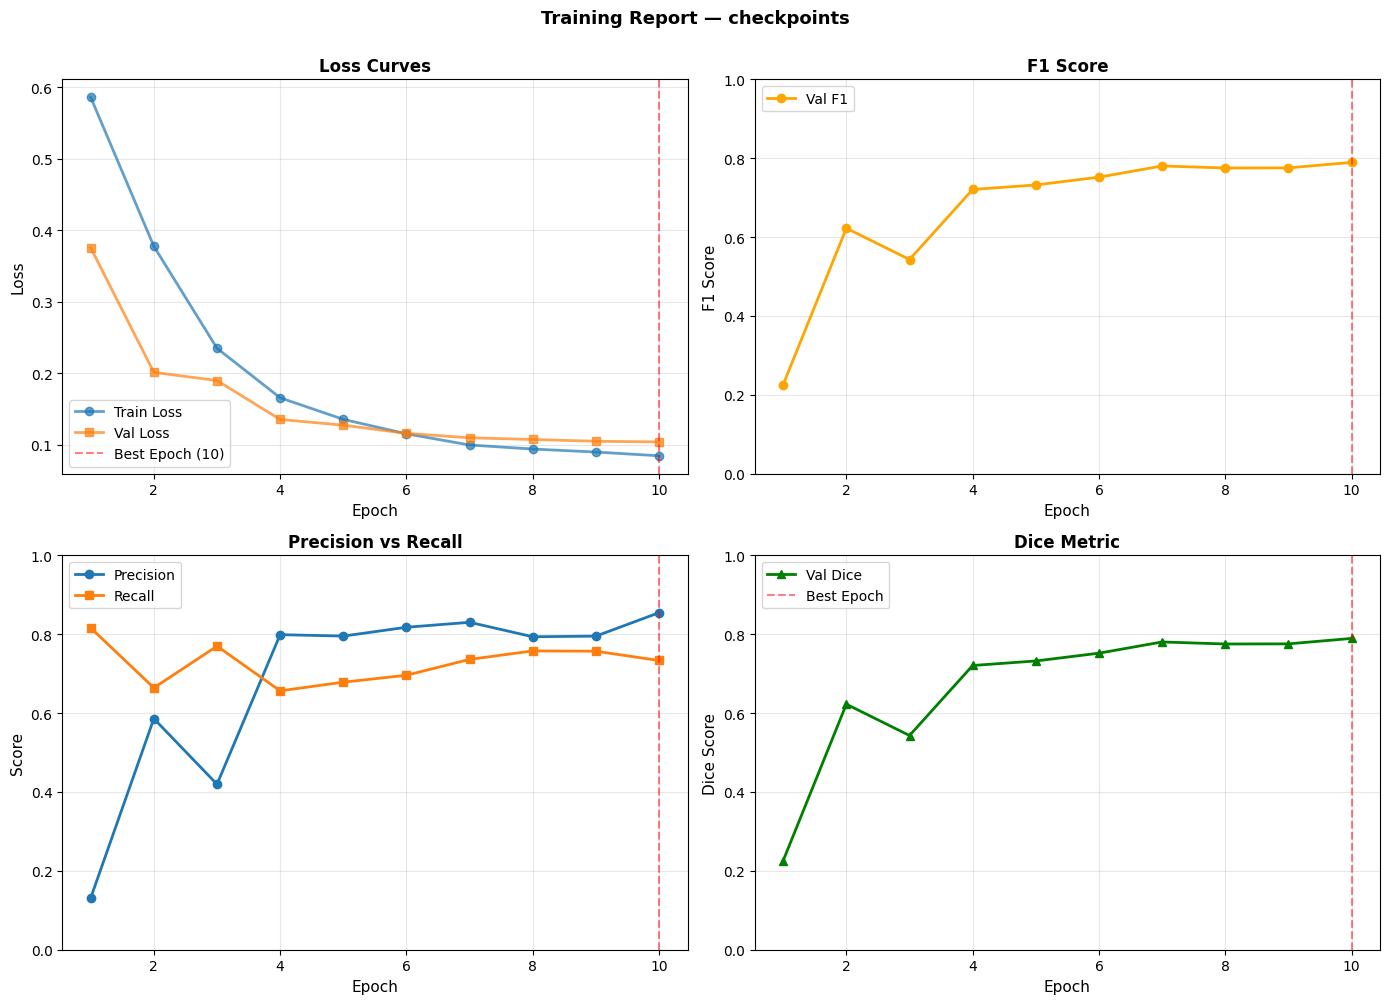

Report: checkpoints\unet_binary_20260510_094651_report.json


In [31]:
# If training finished, visualize the report
report_files = sorted(glob.glob('checkpoints/*_report.json'))
if report_files:
    latest_report = report_files[-1]
    visualize_training_report(latest_report)
    print(f"Report: {latest_report}")

In [32]:
def extract_watershed_instances(
    pred_masks: list,
    pred_probs: list,
    tile_coords: list,
    min_area_px: int = 100,
) -> list:
    """Extract watershed-separated instances from tile probability/mask predictions."""
    all_instances = []

    for bin_mask, prob_map, coords in zip(pred_masks, pred_probs, tile_coords):
        x0_tile, y0_tile, x1_tile, y1_tile = coords
        tile_h, tile_w = bin_mask.shape

        scale_x = (x1_tile - x0_tile) / tile_w
        scale_y = (y1_tile - y0_tile) / tile_h

        distance = _ndi.distance_transform_edt(bin_mask)
        coords_peaks = _plm(distance, min_distance=10, labels=bin_mask)
        if distance.max() > 0 and len(coords_peaks) > 0:
            mask_peaks = np.zeros(distance.shape, dtype=bool)
            mask_peaks[tuple(coords_peaks.T)] = True
            markers, _ = _ndi.label(mask_peaks)
            labels = _watershed(-distance, markers, mask=bin_mask)
        else:
            labels, _ = _ndi.label(bin_mask)

        props = regionprops(labels, intensity_image=prob_map)

        for region in props:
            if region.area < min_area_px:
                continue

            r0, c0, r1, c1 = region.bbox
            bbox = (
                x0_tile + c0 * scale_x,
                y0_tile + r0 * scale_y,
                x0_tile + c1 * scale_x,
                y0_tile + r1 * scale_y,
            )
            all_instances.append((bbox, float(region.mean_intensity)))

    return all_instances


# Backward-compatible alias; this does instance extraction, not cross-tile box NMS.
apply_nms_to_predictions = extract_watershed_instances


## Part 7: Troubleshooting and System Requirements

### Troubleshooting

**"No images found in Salidas/Estandarizados"**
- Run the preprocessing pipeline first (tiling -> normalization -> standardization).

**"CUDA out of memory"**
- Reduce `batch_size` (try 2 or 1)
- Increase `--ram-fraction` in preprocessing scripts
- Use CPU training (slower but uses less VRAM)

**"Expected masks directory"**
- Ensure masks were copied by normalizacion.py and estandarizacion.py to `Salidas/Estandarizados/*/masks/`
- Verify mask naming convention: `{tile_name}_mask.png`

**"No valid image-mask pairs found"**
- Check that image and mask counts match
- Verify paths: images in `*/images/` and masks in `*/masks/`

### System Requirements

- **Python**: 3.10+
- **PyTorch**: 2.0+ (with CUDA if GPU available)
- **RAM**: 16GB minimum, 32GB+ recommended
- **GPU**: Optional but recommended (4GB VRAM minimum)
- **Dependencies**: See requirements.txt (numpy, torch, torchvision, opencv, scikit-learn, albumentations, tensorboard)

### References

- **U-Net**: Ronneberger et al., "U-Net: Convolutional Networks for Biomedical Image Segmentation" (MICCAI 2015)
- **Dice Loss**: Sørensen–Dice coefficient for segmentation evaluation

# Detailed Prediction Evaluation — Ground Truth vs Predictions

This section shows the model's predictions compared to ground truth with pixel-level error analysis.
Each column shows a different view: original image, ground truth mask, predicted mask, overlay, and error map (TP/FP/FN).

In [33]:
def visualize_prediction_comparison(model, image_path, mask_path, device, threshold=0.5, 
                                  reinhard_norm=None, channel_means=None, channel_stds=None):
    """
    Detailed prediction comparison: GT vs Pred with error analysis.
    
    Args:
        model: Trained U-Net model
        image_path: Path to input tile image
        mask_path: Path to ground truth mask
        device: Torch device
        threshold: Probability threshold for binarization
        reinhard_norm: ReinhardNormalize instance
        channel_means: Channel means for Z-score
        channel_stds: Channel stds for Z-score
    """
    model.eval()
    
    # Load and preprocess image
    img_rgb = load_rgb_image(image_path)
    mask_gt_binary = load_binary_mask(mask_path)
    img_preprocessed = preprocess_rgb_image(img_rgb, reinhard_norm, channel_means, channel_stds)
    img_tensor = tensor_from_preprocessed_rgb(img_preprocessed, device)
    
    # Predict
    with torch.no_grad():
        logits = model(img_tensor)
        pred_prob = torch.sigmoid(logits)
    
    pred_prob_np = pred_prob.squeeze().cpu().numpy()
    pred_binary = (pred_prob_np > threshold).astype(np.uint8)
    
    # Compute metrics for this tile
    tp = np.sum((mask_gt_binary == 1) & (pred_binary == 1))
    fp = np.sum((mask_gt_binary == 0) & (pred_binary == 1))
    fn = np.sum((mask_gt_binary == 1) & (pred_binary == 0))
    dice = 2 * tp / (2 * tp + fp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    
    # Create visualizations
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    
    # 1. Original image
    axes[0].imshow(img_rgb)
    axes[0].set_title("1. Original Image", fontweight='bold', fontsize=11)
    axes[0].axis('off')
    
    # 2. Ground truth
    axes[1].imshow(mask_gt_binary, cmap='RdYlGn', vmin=0, vmax=1)
    axes[1].set_title("2. Ground Truth\n(white=glomerulus)", fontweight='bold', fontsize=11)
    axes[1].axis('off')
    
    # 3. Prediction
    axes[2].imshow(pred_binary, cmap='Blues', vmin=0, vmax=1)
    axes[2].set_title(f"3. Predicted Mask\n(threshold={threshold:.2f})", fontweight='bold', fontsize=11)
    axes[2].axis('off')
    
    # 4. Overlay: TP=cyan, GT-only/FN=yellow, Pred-only/FP=red
    overlay = img_rgb.copy().astype(float)
    gt_bool = mask_gt_binary.astype(bool)
    pred_bool = pred_binary.astype(bool)
    overlay[gt_bool & pred_bool] = [0, 255, 255]
    overlay[gt_bool & ~pred_bool] = [255, 255, 0]
    overlay[~gt_bool & pred_bool] = [255, 0, 0]
    overlay = overlay.astype(np.uint8)
    alpha = 0.4
    blended = cv2.addWeighted(img_rgb, 1-alpha, overlay, alpha, 0)
    axes[3].imshow(blended)
    axes[3].set_title("4. Overlay\n(TP=cyan, FN=yellow, FP=red)", fontweight='bold', fontsize=11)
    axes[3].axis('off')
    
    # 5. Error map: TP/FP/FN
    error_map = np.zeros((*mask_gt_binary.shape, 3), dtype=np.uint8)
    error_map[(mask_gt_binary == 1) & (pred_binary == 1)] = [0, 255, 0]    # TP green
    error_map[(mask_gt_binary == 0) & (pred_binary == 1)] = [255, 0, 0]    # FP red
    error_map[(mask_gt_binary == 1) & (pred_binary == 0)] = [255, 255, 0]  # FN yellow
    
    axes[4].imshow(error_map)
    axes[4].set_title("5. Error Map\nTP=green, FP=red, FN=yellow", fontweight='bold', fontsize=11)
    axes[4].axis('off')
    
    # Add metrics as text below
    metrics_text = f"Dice={dice:.3f} | IoU={iou:.3f} | Prec={precision:.3f} | Recall={recall:.3f}"
    fig.text(0.5, 0.02, metrics_text, ha='center', fontsize=11, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f"Prediction Analysis — {Path(image_path).name}", 
                fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()

In [34]:
RUN_QUALITATIVE_EVAL = False

if RUN_QUALITATIVE_EVAL and Path('Salidas/Tiles_UNet').exists():
    # Load model and visualize predictions on test samples
    checkpoint_dir = Path('checkpoints')
    best_checkpoints = sorted(checkpoint_dir.glob('*_best.pth'))
    
    if best_checkpoints:
        best_ckpt = best_checkpoints[-1]
        
        # Load model
        checkpoint = torch.load(best_ckpt, map_location=device)
        model_eval = create_model(**checkpoint.get('model_config', MODEL_CONFIG)).to(device)
        # Extract preprocessing parameters from checkpoint
        channel_means = checkpoint.get('channel_means')
        channel_stds = checkpoint.get('channel_stds')
        reinhard_stats = checkpoint.get('reinhard_stats')
        model_eval.load_state_dict(checkpoint['model_state_dict'])
        
        # Get test samples
        reinhard_norm = ReinhardNormalize(reinhard_stats) if reinhard_stats else None
        ds_test = GlomeruliDataset('Salidas/Tiles_UNet', split='test',
                                 reinhard_norm=reinhard_norm, channel_means=channel_means, channel_stds=channel_stds)
        positive_test_idx = [i for i, flag in enumerate(ds_test.get_positive_flags()) if flag]
        
        if positive_test_idx:
            random.seed(42)
            sample_indices = random.sample(positive_test_idx, min(50, len(positive_test_idx)))
            
            for sample_idx in sample_indices:
                img_path = ds_test.image_paths[sample_idx]
                mask_path = ds_test._get_mask_path(img_path)
                visualize_prediction_comparison(model_eval, img_path, mask_path, device,
                               reinhard_norm=reinhard_norm,
                               channel_means=channel_means,
                               channel_stds=channel_stds)
        
        print(f"Loaded checkpoint: {best_ckpt.name}")
    else:
        print("No trained model checkpoint found")

if not RUN_QUALITATIVE_EVAL:
    print("Qualitative evaluation is disabled. Set RUN_QUALITATIVE_EVAL = True to run it.")


Qualitative evaluation is disabled. Set RUN_QUALITATIVE_EVAL = True to run it.


In [35]:
def debug_prediction_probabilities(model, image_path, mask_path, device,
                                  reinhard_norm=None, channel_means=None, channel_stds=None):
    """Debug: Show raw probabilities (before threshold) and threshold sensitivity."""
    model.eval()
    
    img_rgb = load_rgb_image(image_path)
    mask_gt_binary = load_binary_mask(mask_path)
    img_preprocessed = preprocess_rgb_image(img_rgb, reinhard_norm, channel_means, channel_stds)
    img_tensor = tensor_from_preprocessed_rgb(img_preprocessed, device)
    
    # Predict - GET RAW PROBABILITIES
    with torch.no_grad():
        logits = model(img_tensor)
        pred_prob = torch.sigmoid(logits)
    
    pred_prob_np = pred_prob.squeeze().cpu().numpy()
    
    # Analysis
    print(f"\n{'='*70}")
    print(f"DEBUG: {Path(image_path).name}")
    print(f"{'='*70}")
    print(f"Probability stats:")
    print(f"  Min: {pred_prob_np.min():.4f}")
    print(f"  Max: {pred_prob_np.max():.4f}")
    print(f"  Mean: {pred_prob_np.mean():.4f}")
    print(f"  Median: {np.median(pred_prob_np):.4f}")
    print(f"  Std: {pred_prob_np.std():.4f}")
    print(f"\nGround truth: {mask_gt_binary.sum()} glomerulus pixels out of {mask_gt_binary.size}")
    
    # Test multiple thresholds
    thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
    print(f"\nMetrics at different thresholds:")
    print(f"{'Thresh':<8} {'Pred Px':<10} {'Recall':<10} {'Precision':<10} {'F1':<10}")
    print(f"{'-'*48}")
    
    for thresh in thresholds:
        pred_binary = (pred_prob_np > thresh).astype(np.uint8)
        tp = np.sum((mask_gt_binary == 1) & (pred_binary == 1))
        fp = np.sum((mask_gt_binary == 0) & (pred_binary == 1))
        fn = np.sum((mask_gt_binary == 1) & (pred_binary == 0))
        
        recall = tp / (tp + fn + 1e-8)
        precision = tp / (tp + fp + 1e-8)
        f1 = 2 * tp / (2 * tp + fp + fn + 1e-8)
        pred_pixels = pred_binary.sum()
        
        print(f"{thresh:<8.1f} {pred_pixels:<10} {recall:<10.3f} {precision:<10.3f} {f1:<10.3f}")
    
    # Visualize raw probabilities
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'DEBUG: Raw Probabilities — {Path(image_path).name}', fontsize=14, fontweight='bold')
    
    # Row 1
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('Original Image', fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(mask_gt_binary, cmap='gray')
    axes[0, 1].set_title('Ground Truth', fontweight='bold')
    axes[0, 1].axis('off')
    
    im = axes[0, 2].imshow(pred_prob_np, cmap='hot', vmin=0, vmax=1)
    axes[0, 2].set_title('Raw Probabilities\n(0=black, 1=white)', fontweight='bold')
    plt.colorbar(im, ax=axes[0, 2])
    axes[0, 2].axis('off')
    
    # Row 2: Three different thresholds
    for idx, thresh in enumerate([0.3, 0.5, 0.7]):
        pred_binary = (pred_prob_np > thresh).astype(np.uint8)
        axes[1, idx].imshow(pred_binary, cmap='gray')
        tp = np.sum((mask_gt_binary == 1) & (pred_binary == 1))
        fp = np.sum((mask_gt_binary == 0) & (pred_binary == 1))
        fn = np.sum((mask_gt_binary == 1) & (pred_binary == 0))
        recall = tp / (tp + fn + 1e-8)
        axes[1, idx].set_title(f'Threshold={thresh}\nRecall={recall:.3f}', fontweight='bold')
        axes[1, idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    plt.close()
    
    return pred_prob_np


# ============================================================================
# RUN DEBUG ON A FEW POSITIVE TILES
# ============================================================================
RUN_DEBUG_PROBABILITIES = False

if RUN_DEBUG_PROBABILITIES and Path('Salidas/Tiles_UNet').exists() and 'model_eval' in locals():
    positive_test_idx = [i for i, flag in enumerate(ds_test.get_positive_flags()) if flag]
    
    if positive_test_idx:
        random.seed(42)
        debug_indices = random.sample(positive_test_idx, min(3, len(positive_test_idx)))  # Just 3 for debugging
        
        for sample_idx in debug_indices:
            img_path = ds_test.image_paths[sample_idx]
            mask_path = ds_test._get_mask_path(img_path)
            debug_prediction_probabilities(model_eval, img_path, mask_path, device,
                                          reinhard_norm=reinhard_norm,
                                          channel_means=channel_means,
                                          channel_stds=channel_stds)
elif RUN_DEBUG_PROBABILITIES:
    print("Cannot run debug: model not loaded or no test dataset")
else:
    print("Debug probabilities are disabled. Set RUN_DEBUG_PROBABILITIES = True to run them.")

Debug probabilities are disabled. Set RUN_DEBUG_PROBABILITIES = True to run them.


## Part 8: Qualitative Evaluation — Predictions vs Ground Truth

Visual inspection of model predictions on the test set is critical in medical image segmentation. Quantitative metrics like F1 and accuracy can mask clinically relevant errors such as:
- Imprecise borders around glomeruli (false positives/negatives at edges)
- False positives in glomerulus-like structures (cracks, debris)
- Missed glomeruli in hard-to-segment regions

The cells below visualize predictions alongside ground truth for qualitative assessment.

## Part 9: Instance-Based Threshold Selection

Select decision threshold by optimizing for **instance recall**, not pixel-level F1.
Key insight: missing a glomerulus (FN) is worse than a false positive.
This cell finds the threshold maximizing recall with acceptable precision (≥0.30).

In [36]:
# ===== CENTRALIZED POST-PROCESSING FUNCTION =====
# This function is used by threshold tuning, crop extraction, and reconstruction viz
# to ensure CONSISTENCY across all stages

def postprocess_prob_to_instances(
    prob_map,           # H×W float32 probability map (0-1)
    threshold=0.4,
    min_area_px=1500,
    min_distance=15,    # distance between watershed peaks
):
    """
    Consistent post-processing pipeline for all glomerulus detection tasks.
    
    Args:
        prob_map: H×W float32 array in [0, 1]
        threshold: decision threshold
        min_area_px: minimum instance area in pixels
        min_distance: minimum distance between watershed peaks
    
    Returns:
        list of skimage regionprops objects (instances)
    """
    # Step 1: Binary mask from probability
    binary_mask = (prob_map > threshold).astype(np.uint8)
    
    # Step 2: Morphological cleaning (close → open)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel_close)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel_open)
    
    # Step 3: Watershed-based instance separation
    if binary_mask.sum() < min_area_px:
        return []
    
    distance = distance_transform_edt(binary_mask)
    coords = _plm(distance, min_distance=min_distance, labels=binary_mask)
    
    if len(coords) == 0:
        # Single large region
        coords = np.array([[binary_mask.shape[0]//2, binary_mask.shape[1]//2]])
    
    marker_mask = np.zeros_like(binary_mask, dtype=bool)
    marker_mask[tuple(coords.T)] = True
    markers, _ = scipy_label(marker_mask)
    
    labels_map = _watershed(-distance, markers, mask=binary_mask)
    props = regionprops(labels_map)
    
    # Step 4: Filter by minimum area
    return [p for p in props if p.area >= min_area_px]


In [37]:
def tune_threshold_by_instance_recall(
    model, dataloader, device,
    thresholds=None,
    min_precision=0.30,
    min_area_px=1500,
    iou_match_threshold=0.3,
) -> float:
    """Find optimal decision threshold by optimizing instance recall (reuses centralized post-processing)."""
    if thresholds is None:
        thresholds = [0.20, 0.30, 0.40, 0.50, 0.60]
    
    print("🔍 Collecting predictions for instance-based threshold tuning...")
    all_pred_probs = []
    all_gt_masks = []
    
    model.eval()
    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(tqdm(dataloader, desc='Inference')):
            images = images.to(device)
            masks = masks.cpu().numpy()
            with autocast():
                logits = model(images)
            pred_probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
            for i in range(len(images)):
                all_pred_probs.append(pred_probs[i])
                all_gt_masks.append(masks[i])
    
    print(f"✓ Collected {len(all_pred_probs)} tiles")
    
    def _iou(box1, box2):
        y1_min, x1_min, y1_max, x1_max = box1
        y2_min, x2_min, y2_max, x2_max = box2
        inter_y_min = max(y1_min, y2_min)
        inter_x_min = max(x1_min, x2_min)
        inter_y_max = min(y1_max, y2_max)
        inter_x_max = min(x1_max, x2_max)
        if inter_y_max < inter_y_min or inter_x_max < inter_x_min:
            return 0.0
        inter = (inter_y_max - inter_y_min) * (inter_x_max - inter_x_min)
        union = ((y1_max - y1_min) * (x1_max - x1_min) + (y2_max - y2_min) * (x2_max - x2_min) - inter)
        return inter / (union + 1e-6)
    
    results = []
    print("\n📊 Evaluating thresholds (all use SAME post-processing pipeline):")
    print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'F1':<10} {'n_Detected':<12}")
    print("-" * 60)
    
    for threshold in thresholds:
        tp, fp, fn = 0, 0, 0
        
        for pred_prob, gt_mask in zip(all_pred_probs, all_gt_masks):
            # USE CENTRALIZED FUNCTION
            pred_props = postprocess_prob_to_instances(pred_prob, threshold, min_area_px)
            
            # GT uses same post-processing
            gt_binary = (gt_mask > 0).astype(np.float32)
            gt_props = postprocess_prob_to_instances(gt_binary, 0.5, min_area_px)
            
            pred_boxes = [p.bbox for p in pred_props]
            gt_boxes = [p.bbox for p in gt_props]
            matched = [False] * len(gt_boxes)
            
            for pb in pred_boxes:
                best_idx = -1
                best_iou = iou_match_threshold
                for gi, gb in enumerate(gt_boxes):
                    if matched[gi]:
                        continue
                    iou = _iou(pb, gb)
                    if iou > best_iou:
                        best_iou = iou
                        best_idx = gi
                if best_idx >= 0:
                    matched[best_idx] = True
                    tp += 1
                else:
                    fp += 1
            fn += sum(1 for m in matched if not m)
        
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1 = 2 * (recall * precision) / (recall + precision + 1e-6)
        n_detected = tp + fp
        
        print(f"{threshold:<12.2f} {recall:<10.3f} {precision:<12.3f} {f1:<10.3f} {n_detected:<12d}")
        results.append({'threshold': threshold, 'recall': recall, 'precision': precision, 'f1': f1})
    
    valid = [r for r in results if r['precision'] >= min_precision]
    best = max(valid, key=lambda x: x['recall']) if valid else max(results, key=lambda x: x['recall'])
    
    print(f"\n✅ Selected threshold: {best['threshold']:.2f} (recall={best['recall']:.3f}, precision={best['precision']:.3f})")
    return best['threshold']

In [38]:
RUN_INSTANCE_THRESHOLD = True

if RUN_INSTANCE_THRESHOLD and 'model' in dir() and 'val_loader' in dir():
    best_threshold_instance = tune_threshold_by_instance_recall(
        model, val_loader, device,
        thresholds=[0.20, 0.30, 0.40, 0.50, 0.60],
        min_precision=0.30,
        min_area_px=2500,
    )
    print(f"\n🎯 Instance-optimized threshold: {best_threshold_instance:.2f}")
elif RUN_INSTANCE_THRESHOLD:
    print("⚠️  Run train_unet() first.")


🔍 Collecting predictions for instance-based threshold tuning...


Inference:   0%|          | 0/504 [00:00<?, ?it/s]C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_4792\1685530827.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Inference: 100%|██████████| 504/504 [06:55<00:00,  1.21it/s]


✓ Collected 2013 tiles

📊 Evaluating thresholds (all use SAME post-processing pipeline):
Threshold    Recall     Precision    F1         n_Detected  
------------------------------------------------------------
0.20         0.568      0.323        0.412      1389        
0.30         0.554      0.337        0.419      1299        
0.40         0.545      0.351        0.427      1227        
0.50         0.536      0.368        0.437      1151        
0.60         0.521      0.371        0.433      1112        

✅ Selected threshold: 0.20 (recall=0.568, precision=0.323)

🎯 Instance-optimized threshold: 0.20


# ⚠️ IMPORTANT: Checkpoint Selection Strategy (Current vs Recommended)

## Current Approach
✓ Checkpoint saved during training based on **pixel-level F1** (cell 29, `train_unet`)
✓ After training: instance-based threshold tuning (cell 47)

## Issue
- If pixel F1 and instance recall are **inversely correlated**, we may have selected the WRONG checkpoint
  - Example: model A: pixel F1=0.92 but instance recall=0.65 (fragments glomeruli)
  - Example: model B: pixel F1=0.89 but instance recall=0.78 (cleaner separation)
  - We saved model A, but should have saved model B

## Recommended Improvement (for next iteration)
Instead of OR in addition to pixel F1, track during validation:

```python
# In train_unet() validation loop (cell 29):
# After each epoch, compute instance metrics
val_instance_metrics = compute_instance_metrics(model, val_loader, device, threshold=0.5, min_area_px=2500)

# Save best checkpoint by:
# 1. Primary: instance_recall (avoid missing glomeruli)
# 2. Secondary: instance_f1 (avoid over-segmentation)
# 3. Backup: pixel_f1 if instance metrics don't improve
```

## How to Implement
1. Modify `train_unet()` to track instance metrics during validation
2. Save multiple checkpoints: best_pixel_f1, best_instance_recall, best_instance_f1
3. After training, evaluate all three and pick the best for downstream tasks

## For Now
✅ You have `best_threshold_instance` from cell 47
→ Use this to evaluate which checkpoint is actually best:

```python
# (After cell 47 finishes)
# Reload best_pixel_f1 checkpoint and evaluate with best_threshold_instance
# Compare against other candidate checkpoints
```

This will be a task for Phase 2 implementation.


## Part 10: Post-Processing Pipeline — Mask → Instances → Crops

Extract individual glomerulus patches for the downstream classifier.

Pipeline: Inference → Morph clean → Watershed → Expand bbox → Crop → Save PNG

In [60]:
def extract_glomerulus_crops(model, dataloader, device, threshold, min_area_px=1500, margin_ratio=0.25, crop_size=(224, 224), output_dir='Salidas/Crops_Glomerulos', channel_means=None, channel_stds=None):
    """Extract individual glomerulus crops using CENTRALIZED post-processing."""
    os.makedirs(output_dir, exist_ok=True)
    if channel_means is None:
        channel_means = [0.5, 0.5, 0.5]
    if channel_stds is None:
        channel_stds = [0.2, 0.2, 0.2]
    channel_means = np.array(channel_means, dtype=np.float32)
    channel_stds = np.array(channel_stds, dtype=np.float32)
    
    rows, global_idx = [], 0
    model.eval()
    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(tqdm(dataloader, desc='Crops')):
            images = images.to(device)
            images_np, masks_np = images.cpu().numpy(), masks.cpu().numpy()
            with autocast():
                logits = model(images)
            pred_probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
            
            for i in range(len(images)):
                tile_path = Path(dataloader.dataset.image_paths[global_idx])
                slide_id = tile_path.stem.split('_tile_')[0].replace('_centered_g', '').split('_')[0]
                m = re.search(r'_tile_x(\d+)_y(\d+)_endx(\d+)_endy(\d+)', tile_path.stem)
                tile_x0, tile_y0 = (int(m.group(1)), int(m.group(2))) if m else (0, 0)
                
                img_np = (images_np[i].transpose(1, 2, 0) * channel_stds + channel_means)
                img_np = np.clip(img_np, 0, 1)
                pred_prob, gt_mask = pred_probs[i], masks_np[i]
                
                # USE CENTRALIZED FUNCTION
                props = postprocess_prob_to_instances(pred_prob, threshold, min_area_px)
                if len(props) == 0:
                    global_idx += 1
                    continue
                
                for instance_id, prop in enumerate(props):
                    min_row, min_col, max_row, max_col = prop.bbox
                    centroid_row, centroid_col = prop.centroid
                    mask_area, mean_prob = prop.area, pred_prob[min_row:max_row, min_col:max_col].mean()
                    max_prob = pred_prob[min_row:max_row, min_col:max_col].max()
                    
                    h, w = max_row - min_row, max_col - min_col
                    pad_r, pad_c = int(h * margin_ratio), int(w * margin_ratio)
                    bbox_min_row, bbox_min_col = max(0, min_row - pad_r), max(0, min_col - pad_c)
                    bbox_max_row, bbox_max_col = min(img_np.shape[0], max_row + pad_r), min(img_np.shape[1], max_col + pad_c)
                    
                    crop_img = cv2.resize(img_np[bbox_min_row:bbox_max_row, bbox_min_col:bbox_max_col], crop_size)
                    slide_dir = Path(output_dir) / slide_id
                    slide_dir.mkdir(parents=True, exist_ok=True)
                    crop_path = slide_dir / f"{tile_path.stem}_inst{instance_id:04d}.png"
                    cv2.imwrite(str(crop_path), cv2.cvtColor((crop_img * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
                    
                    rows.append({'slide_id': slide_id, 'tile_path': str(tile_path), 'instance_id': instance_id,
                        'bbox_tile_min_row': min_row, 'bbox_tile_min_col': min_col, 'bbox_tile_max_row': max_row, 'bbox_tile_max_col': max_col,
                        'centroid_row': float(centroid_row), 'centroid_col': float(centroid_col),
                        'wsi_x1': tile_x0 + bbox_min_col, 'wsi_y1': tile_y0 + bbox_min_row,
                        'wsi_x2': tile_x0 + bbox_max_col, 'wsi_y2': tile_y0 + bbox_max_row,
                        'mask_area': int(mask_area), 'mean_prob': float(mean_prob), 'max_prob': float(max_prob), 'crop_path': str(crop_path)})
                global_idx += 1
    
    print(f"✓ Extracted {len(rows)} glomerulus crops (all using same post-processing)")
    return pd.DataFrame(rows)

In [61]:
RUN_CROP_EXTRACTION = True

if RUN_CROP_EXTRACTION and 'model' in dir() and 'test_loader' in dir():
    threshold_for_crops = best_threshold_instance if 'best_threshold_instance' in dir() else 0.4
    crops_df = extract_glomerulus_crops(model, test_loader, device, threshold=threshold_for_crops, min_area_px=2500,
        margin_ratio=0.25, crop_size=(224, 224), output_dir='Salidas/Crops_Glomerulos',
        channel_means=channel_means if 'channel_means' in dir() else None,
        channel_stds=channel_stds if 'channel_stds' in dir() else None)
    out_csv = Path('Salidas/glomerulus_instances.csv')
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    crops_df.to_csv(out_csv, index=False)
    print(f"✅ Saved {len(crops_df)} instances → {out_csv}")
    print(f"\nPer-slide instance counts:\n{crops_df.groupby('slide_id').size().rename('n_instances').to_string()}")
elif RUN_CROP_EXTRACTION:
    print("⚠️  Run train_unet() first.")


Crops:   0%|          | 0/618 [00:00<?, ?it/s]C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_4792\3129993525.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Crops: 100%|██████████| 618/618 [11:08<00:00,  1.08s/it]

✓ Extracted 1952 glomerulus crops (all using same post-processing)
✅ Saved 1952 instances → Salidas\glomerulus_instances.csv

Per-slide instance counts:
slide_id
164-19                                        438
164-190003                                      1
164-190008                                      2
164-190011                                      1
164-190018                                      2
29-10399                                      115
29-103990002                                    1
29-103990006                                    3
29-103990007                                    2
29-103990013                                    2
29-103990019                                    4
29-103990021                                    5
29-103990030                                    1
29-103990043                                    1
29-103990045                                    2
34-10240                                       34
34-102400003                          

## Part 11: Full-Slide Inference & Reconstruction

**Objetivo:** Inferencia en biopsia completa no vista (BR-036-PAS-25-CONV), reconstrucción del slide predicho en espacio nativo, y comparación visual con el original.

**Diferencia vs. training tiles:** Sin watershed ni instancias separadas — glomérulo como región continua binaria.

In [ ]:
def _scaled_dims(w: int, h: int, zoom_scale: float, recon_scale: int) -> tuple:
    """Scaled tile dimensions accounting for zoom and recon scale."""
    tile_native_w = int(w / zoom_scale)
    tile_native_h = int(h / zoom_scale)
    return max(1, tile_native_w // recon_scale), max(1, tile_native_h // recon_scale)


class BiopsyInferenceDataset(Dataset):
    """Load tiles from a single biopsy for inference — no masks required."""
    
    def __init__(
        self,
        slide_dir: Path,
        reinhard_norm=None,
        channel_means=None,
        channel_stds=None,
        size: int = 1024,
    ):
        self.slide_dir = Path(slide_dir)
        
        # Load tile metadata from annotations.json
        annotations_path = self.slide_dir / 'annotations.json'
        if not annotations_path.exists():
            raise FileNotFoundError(f"Missing: {annotations_path}")
        
        with open(annotations_path, 'r') as f:
            annotations = json.load(f)
        
        self.tiles = annotations.get('tiles', [])
        self.reinhard_norm = reinhard_norm
        self.channel_means = channel_means
        self.channel_stds = channel_stds
        
        # Validation transforms (no augmentation)
        _, self.val_tfm = get_transforms(size=size)
    
    def __len__(self) -> int:
        return len(self.tiles)
    
    def __getitem__(self, idx: int) -> tuple:
        """Return (tensor, tile_image_relpath) for lookup during reconstruction.
        
        NOTE: Returns CHW tensor (no batch dim) — DataLoader adds batch dimension.
        """
        tile_meta = self.tiles[idx]
        img_rel_path = tile_meta['image']
        img_path = self.slide_dir / img_rel_path
        
        if not img_path.exists():
            raise FileNotFoundError(f"Missing tile image: {img_path}")
        
        # Load as PIL RGB
        img_pil = Image.open(img_path).convert('RGB')
        img_rgb = np.array(img_pil)
        
        # Apply validation transforms (no-op for val)
        if self.val_tfm:
            augmented = self.val_tfm(image=img_rgb)
            img_rgb = augmented['image']
        
        # Apply full preprocessing: Reinhard + Z-score
        img_float = preprocess_rgb_image(
            img_rgb,
            reinhard_norm=self.reinhard_norm,
            channel_means=self.channel_means,
            channel_stds=self.channel_stds,
        )
        
        # Convert to CHW tensor (NO unsqueeze — DataLoader adds batch dim)
        tensor = torch.from_numpy(np.transpose(img_float, (2, 0, 1))).float()
        
        return tensor, img_rel_path



In [ ]:
def run_biopsy_inference(
    slide_dir: Path,
    model: torch.nn.Module,
    reinhard_norm,
    channel_means,
    channel_stds,
    threshold: float,
    device,
    batch_size: int = 4,
) -> dict:
    """Run inference on all tiles of a biopsy, return {tile_image_relpath: binary_mask_uint8}."""
    ds = BiopsyInferenceDataset(
        slide_dir,
        reinhard_norm=reinhard_norm,
        channel_means=channel_means,
        channel_stds=channel_stds,
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    
    predictions = {}
    model.eval()
    
    with torch.no_grad():
        for batch_tensors, tile_names in tqdm(loader, desc='Inferencia BR-036'):
            batch_tensors = batch_tensors.to(device)
            logits = model(batch_tensors)
            probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()  # [B, H, W]
            
            for prob, tile_name in zip(probs, tile_names):
                binary_mask = (prob >= threshold).astype(np.uint8) * 255
                predictions[tile_name] = binary_mask
    
    return predictions


def reconstruct_from_predictions(
    slide_name: str,
    tiles_dir: Path,
    predictions: dict,
    recon_scale: int = 10,
) -> tuple:
    """Reconstruct full-slide image and predicted binary mask from tile predictions.
    
    Returns: (img_canvas, pred_canvas) as np.ndarray (RGB uint8, L uint8)
    """
    slide_dir = Path(tiles_dir) / slide_name
    annotations_path = slide_dir / 'annotations.json'
    
    if not annotations_path.exists():
        raise FileNotFoundError(f"Missing annotations: {annotations_path}")
    
    with open(annotations_path, 'r') as f:
        annotations = json.load(f)
    
    native_width = annotations['width_native']
    native_height = annotations['height_native']
    zoom_scale = annotations['tiling_config']['zoom_scale']
    tiles = annotations['tiles']
    
    canvas_w = max(1, native_width // recon_scale)
    canvas_h = max(1, native_height // recon_scale)
    
    # Canvas: image (white bg) + mask (black bg)
    img_canvas = np.ones((canvas_h, canvas_w, 3), dtype=np.uint8) * 255
    pred_canvas = np.zeros((canvas_h, canvas_w), dtype=np.uint8)
    
    print(f"Canvas: {canvas_w} x {canvas_h} (native {native_width} x {native_height}, scale 1/{recon_scale})")
    
    for tile_data in tqdm(tiles, desc='Reconstrucci\u00f3n'):
        origin = tile_data['origin_native']
        scaled_x = origin[0] // recon_scale
        scaled_y = origin[1] // recon_scale
        
        # Paste image tile
        img_path = slide_dir / tile_data['image']
        if img_path.exists():
            try:
                tile_img = Image.open(img_path).convert('RGB')
                w_s, h_s = _scaled_dims(tile_img.width, tile_img.height, zoom_scale, recon_scale)
                tile_img_scaled = tile_img.resize((w_s, h_s), Image.LANCZOS)
                tile_img_arr = np.array(tile_img_scaled)
                
                # Paste with bounds check
                y_end = min(scaled_y + h_s, canvas_h)
                x_end = min(scaled_x + w_s, canvas_w)
                img_canvas[scaled_y:y_end, scaled_x:x_end] = tile_img_arr[:y_end-scaled_y, :x_end-scaled_x]
            except Exception as e:
                print(f"  Warning: Failed to load image {img_path}: {e}")
        
        # Paste predicted mask (np.maximum for overlap handling)
        tile_key = tile_data['image']
        if tile_key in predictions:
            try:
                pred_mask = predictions[tile_key]  # uint8 [H, W]
                pred_img = Image.fromarray(pred_mask)
                w_s, h_s = _scaled_dims(pred_img.width, pred_img.height, zoom_scale, recon_scale)
                pred_scaled_img = pred_img.resize((w_s, h_s), Image.NEAREST)
                pred_scaled = np.array(pred_scaled_img)
                
                # Use maximum for OR operation (preserve all glomerulus pixels)
                y_end = min(scaled_y + h_s, canvas_h)
                x_end = min(scaled_x + w_s, canvas_w)
                pred_region = pred_canvas[scaled_y:y_end, scaled_x:x_end]
                pred_scaled_clipped = pred_scaled[:y_end-scaled_y, :x_end-scaled_x]
                pred_canvas[scaled_y:y_end, scaled_x:x_end] = np.maximum(pred_region, pred_scaled_clipped)
            except Exception as e:
                print(f"  Warning: Failed to reconstruct mask {tile_key}: {e}")
    
    return img_canvas, pred_canvas


def reconstruct_gt_mask(
    slide_name: str,
    tiles_dir: Path,
    recon_scale: int = 10,
) -> np.ndarray | None:
    """Reconstruct GT mask from disk (if it exists). Returns None if no masks found."""
    slide_dir = Path(tiles_dir) / slide_name
    masks_dir = slide_dir / 'masks'
    
    if not masks_dir.exists():
        print(f"GT masks directory not found: {masks_dir}")
        return None
    
    annotations_path = slide_dir / 'annotations.json'
    if not annotations_path.exists():
        return None
    
    with open(annotations_path, 'r') as f:
        annotations = json.load(f)
    
    native_width = annotations['width_native']
    native_height = annotations['height_native']
    zoom_scale = annotations['tiling_config']['zoom_scale']
    tiles = annotations['tiles']
    
    canvas_w = max(1, native_width // recon_scale)
    canvas_h = max(1, native_height // recon_scale)
    gt_canvas = np.zeros((canvas_h, canvas_w), dtype=np.uint8)
    
    for tile_data in tiles:
        origin = tile_data['origin_native']
        mask_path = slide_dir / tile_data.get('mask', '')
        
        if not mask_path.exists():
            continue
        
        scaled_x = origin[0] // recon_scale
        scaled_y = origin[1] // recon_scale
        
        try:
            tile_mask = Image.open(mask_path).convert('L')
            w_s, h_s = _scaled_dims(tile_mask.width, tile_mask.height, zoom_scale, recon_scale)
            mask_scaled = tile_mask.resize((w_s, h_s), Image.NEAREST)
            mask_arr = np.array(mask_scaled)
            
            y_end = min(scaled_y + h_s, canvas_h)
            x_end = min(scaled_x + w_s, canvas_w)
            gt_region = gt_canvas[scaled_y:y_end, scaled_x:x_end]
            mask_clipped = mask_arr[:y_end-scaled_y, :x_end-scaled_x]
            gt_canvas[scaled_y:y_end, scaled_x:x_end] = np.maximum(gt_region, mask_clipped)
        except Exception as e:
            print(f"  Warning: Failed to reconstruct GT mask {mask_path}: {e}")
    
    if gt_canvas.sum() == 0:
        print("GT canvas is empty (no masks found).")
        return None
    
    return gt_canvas



In [ ]:
# ─── DEBUG: Entender el conteo de tiles ───────────────────────
# Si el biopsy tiene 156 archivos PNG pero annotations.json solo lista ~39,
# es porque:
#   1. Centered glomerulus tiles (focused crops) — separados
#   2. Regular grid tiles — la mayoría en 2048px steps
#   3. Algunos biopsies pueden tener tiles adicionales no indexados

DEBUG_BIOPSY = 'BR-036-PAS-25-CONV'  # o 933-10155, o BR-029-PAS-25 NUEVA IMAGEN-CONV
TILES_DIR = Path('Salidas/Tiles_UNet')

biopsy_path = TILES_DIR / DEBUG_BIOPSY
if biopsy_path.exists():
    images_dir = biopsy_path / 'images'
    masks_dir = biopsy_path / 'masks'
    ann_file = biopsy_path / 'annotations.json'
    
    pngs = sorted(images_dir.glob('*.png')) if images_dir.exists() else []
    n_actual = len(pngs)
    
    n_annotated = 0
    if ann_file.exists():
        with open(ann_file, 'r') as f:
            ann = json.load(f)
        n_annotated = len(ann.get('tiles', []))
    
    centered_tiles = [p.name for p in pngs if '_centered_g' in p.name]
    grid_tiles = [p.name for p in pngs if '_tile_' in p.name]
    
    print(f"BIOPSY: {DEBUG_BIOPSY}")
    print(f"  PNG files en disk:      {n_actual}")
    print(f"  Tiles en annotations:  {n_annotated}")
    print(f"    - Grid tiles:        {len(grid_tiles)}")
    print(f"    - Centered tiles:    {len(centered_tiles)}")
    print(f"  Masks en disk:         {len(list(masks_dir.glob('*.png'))) if masks_dir.exists() else 0}")
    print(f"\nℹ️  Si PNG files ≠ annotations, algunos tiles no están indexados.")
    print(f"    Esto puede ser OK si usas solo tiles anotados.")
else:
    print(f"❌ Biopsy not found: {biopsy_path}")
    print(f"   Biopsies available:")
    for b in sorted(TILES_DIR.iterdir()):
        if b.is_dir():
            print(f"     - {b.name}")


In [ ]:
RUN_BIOPSY_RECONSTRUCTION = True

if RUN_BIOPSY_RECONSTRUCTION:
    # Guards
    assert 'model' in dir() and model is not None, "Load checkpoint first (Cell 35)"
    
    BIOPSY_TO_INFER = 'BR-036-PAS-25-CONV'
    RECON_SCALE = 10
    OVERLAY_ALPHA = 180
    TILES_DIR = Path('Salidas/Tiles_UNet')
    
    slide_dir = TILES_DIR / BIOPSY_TO_INFER
    assert slide_dir.exists(), f"Biopsy not found: {slide_dir}"
    
    print(f"\n{'='*60}")
    print(f"INFERENCIA + RECONSTRUCCI\u00d3N: {BIOPSY_TO_INFER}")
    print(f"{'='*60}\n")
    
    # 1. Run inference
    predictions = run_biopsy_inference(
        slide_dir, model, _reinhard_norm, _channel_means, _channel_stds,
        best_threshold, device, batch_size=4
    )
    print(f"\n✓ Tiles inferidos: {len(predictions)}")
    
    # 2. Reconstruct predicted mask
    img_canvas, pred_canvas = reconstruct_from_predictions(
        BIOPSY_TO_INFER, TILES_DIR, predictions, recon_scale=RECON_SCALE
    )
    print(f"\n✓ Reconstrucci\u00f3n completada: {img_canvas.shape}")
    
    # 3. Try to load GT mask for comparison
    gt_canvas = reconstruct_gt_mask(BIOPSY_TO_INFER, TILES_DIR, recon_scale=RECON_SCALE)
    if gt_canvas is not None:
        print(f"✓ GT mask reconstruida: {gt_canvas.shape}")
    
    # 4. Create overlay: red semi-transparent mask on original image
    overlay = img_canvas.copy().astype(np.float32)
    pred_mask_bool = pred_canvas > 0
    overlay[pred_mask_bool] = overlay[pred_mask_bool] * 0.5 + np.array([255, 0, 0]) * 0.5
    overlay = overlay.astype(np.uint8)
    
    # 5. Save outputs
    out_dir = slide_dir / 'reconstructions'
    out_dir.mkdir(parents=True, exist_ok=True)
    
    Image.fromarray(img_canvas).save(out_dir / f'{BIOPSY_TO_INFER}_reconstruction.png')
    Image.fromarray(pred_canvas).save(out_dir / f'{BIOPSY_TO_INFER}_predicted_mask.png')
    Image.fromarray(overlay).save(out_dir / f'{BIOPSY_TO_INFER}_predicted_overlay.png')
    
    if gt_canvas is not None:
        Image.fromarray(gt_canvas).save(out_dir / f'{BIOPSY_TO_INFER}_gt_mask.png')
    
    print(f"\n✓ Outputs guardados en: {out_dir}")
    
    # 6. Visualization
    n_cols = 4 if gt_canvas is not None else 3
    fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 10))
    if n_cols == 3:
        axes = np.atleast_1d(axes)
    
    axes[0].imshow(img_canvas)
    axes[0].set_title('Imagen Original Reconstruida', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(pred_canvas, cmap='hot')
    axes[1].set_title(f'M\u00e1scara Predicha (thr={best_threshold:.2f})', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay Predicho', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    if gt_canvas is not None:
        axes[3].imshow(gt_canvas, cmap='hot')
        axes[3].set_title('M\u00e1scara GT', fontsize=12, fontweight='bold')
        axes[3].axis('off')
    
    plt.tight_layout()
    plt.savefig(out_dir / f'{BIOPSY_TO_INFER}_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Figura comparativa guardada en: {out_dir}/{BIOPSY_TO_INFER}_comparison.png")

